# LCA + PDA Integrated Analysis — Chilean Household Heating (2018–2024)
## Version 05062026v1 · 2026-06-05

---
## Paper figures produced by this notebook

| Cell | Output file | Description | Paper location |
|------|------------|-------------|----------------|
| 8  | `FIGURE_1_context` | PM₂.₅ + programme progress + tech mix + zone contribution (4 panels) | Main text, Section 2 |
| 10 | `FIGURE_2_hh_upstream_split` | Household vs upstream decomposition | Main text, Section 4.1 |
| 17 | `FIGURE_3_external_costs` | External costs, both scenarios | Main text, Section 4.2 |
| 17 | `FIGURE_4_biogenic_comparison` | Biogenic scenario comparison (3 panels) | Main text, Section 4.2 |
| 13 | `APPENDIX_A2_pm25_avoided_by_zone` | PM₂.₅ avoided by zone (stacked area) | Appendix A |

## Paper tables

| Cell | Output file | Paper location |
|------|------------|----------------|
| 18 | `TABLE_1_LCA_per_kWh.csv` | Main text, Tab. 1 |
| 18 | `TABLE_2_PDA_summary.csv` | Main text, Tab. 2 |
| 18 | `TABLE_3_external_costs.csv` | Appendix B |
| 18 | `TABLE_4_cost_effectiveness.csv` | Appendix B |

## ⚠ Parameters to set before submission

| Parameter | Current | Submission | Cell |
|-----------|---------|------------|------|
| `N_ITER` | 10 | **1 000** | 5 |
| `FX_CLP_PER_USD` | 900 | **830** | 1 |

## Cell map

| Cell | Role |
|------|------|
| 0  | This cover |
| 1  | Global config |
| 2  | Brightway2 setup |
| 3  | LCI activities (7 pathways) |
| 4  | Deterministic LCA, both scenarios |
| 5  | Monte Carlo uncertainty |
| 6  | In-memory LCA bridge |
| 7  | *(separator)* |
| 8  | **FIGURE 1** — 4-panel context figure |
| 9  | *(separator)* Part I |
| 10 | **FIGURE 2** — Household vs upstream |
| 11 | *(separator)* Part II |
| 12 | PDA data loading |
| 13 | Firewood transition data pipeline |
| 14 | Emissions bridge |
| 15 | *(separator)* Part III |
| 16 | **APPENDIX A2** — PM₂.₅ avoided by zone |
| 17 | *(separator)* Part IV |
| 18 | **FIGURE 3 + 4** — External costs + biogenic comparison |
| 19 | **PAPER TABLES** — CSV export |
| 20 | Runtime report |


In [1]:
# =============================================================================
# CELL 1 — GLOBAL CONFIGURATION
# =============================================================================
# All paths, constants, palettes, and helpers used by every downstream cell.
#
# BEFORE RUNNING:
#   1. Set ASSUMPTIONS_FILE to your local path of AssumptionsLCAPDA_updated.xlsx
#   2. Set FX_CLP_PER_USD = 830 for the submission run (current value is a dev
#      approximation; the paper reports 830 CLP/USD as the period-average rate)
#   3. Set N_ITER = 1000 in Cell 5 before the production run
# =============================================================================

import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

NOTEBOOK_VERSION    = "04062026v4"
NOTEBOOK_START_TIME = time.time()
print(f"⏱  Notebook {NOTEBOOK_VERSION} — {time.strftime('%Y-%m-%d %H:%M:%S')}")

# ─── PATHS ────────────────────────────────────────────────────────────────────
ASSUMPTIONS_FILE = Path(
    r"C:\Users\uribep_a\OneDrive - Paul Scherrer Institut"
    r"\general_LCA\AssumptionsLCAPDA_updated.xlsx"
)
if not ASSUMPTIONS_FILE.exists():
    _fb = Path("AssumptionsLCAPDA_updated.xlsx")
    if _fb.exists():
        ASSUMPTIONS_FILE = _fb
        print(f"  ↳ Using relative path: {ASSUMPTIONS_FILE}")

OUTPUT_DIR = Path.cwd() / "paper_outputs_LCA_PDA"

# Path to the SINIA PM2.5 p98 CSV (used for Figure 1 context map).
# Download from: https://sinia.mma.gob.cl/estado-del-medio-ambiente/
# Default: look for the file in the working directory.
PM25_CSV_FILE = Path("SINIA_PM25_p98_2017_2024.csv")
if not PM25_CSV_FILE.exists():
    _fb_pm = Path("data/SINIA_PM25_p98_2017_2024.csv")
    if _fb_pm.exists():
        PM25_CSV_FILE = _fb_pm
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── PHYSICAL CONSTANTS ───────────────────────────────────────────────────────
MJ_PER_KWH                = 3.6        # MJ per kWh
USEFUL_HEAT_KWH_PER_STOVE = 12_000     # kWh / stove / year

# ─── MONETARY CONSTANTS ───────────────────────────────────────────────────────
SCC_LOW, SCC_CENTRAL, SCC_HIGH           = 50, 80, 150      # USD / tCO2-eq
V_DALY_LOW, V_DALY_CENTRAL, V_DALY_HIGH = 40_000, 80_000, 120_000  # USD / DALY
DALY_PER_KG_PM25                         = 0.000629         # from EF v3.0

# ⚠ Use 830 for submission (period-average 2018–2024 nominal rate).
FX_CLP_PER_USD = 900.0

# ─── TECHNOLOGY ORDER AND LABELS ──────────────────────────────────────────────
TECH_ORDER = [
    "firewood_wet", "firewood_dry",
    "pellet_imported", "pellet_domestic",
    "electricity", "kerosene", "lpg",
]
TECH_LABELS = {
    "firewood_wet":    "Firewood\n(wet)",
    "firewood_dry":    "Firewood\n(dry)",
    "pellet_domestic": "Pellet\n(domestic)",
    "pellet_imported": "Pellet\n(imported)",
    "electricity":     "Electricity",
    "kerosene":        "Kerosene",
    "lpg":             "LPG",
}
SCENARIO_META = {
    "firewood_wet":    {"label":"Firewood wet",    "group":"firewood",    "role":"baseline"},
    "firewood_dry":    {"label":"Firewood dry",    "group":"firewood",    "role":"sensitivity"},
    "pellet_domestic": {"label":"Pellet domestic", "group":"pellet",      "role":"policy"},
    "pellet_imported": {"label":"Pellet imported", "group":"pellet",      "role":"sensitivity"},
    "electricity":     {"label":"Electricity",     "group":"electricity", "role":"future"},
    "lpg":             {"label":"LPG",             "group":"lpg",         "role":"alternative"},
    "kerosene":        {"label":"Kerosene",        "group":"kerosene",    "role":"alternative"},
}

# ─── COLOUR PALETTES ──────────────────────────────────────────────────────────
COLORS_TECH = {
    "firewood_wet":    "#d62728",
    "firewood_dry":    "#ff7f0e",
    "pellet_domestic": "#2ca02c",
    "pellet_imported": "#17becf",
    "electricity":     "#1f77b4",
    "lpg":             "#9467bd",
    "kerosene":        "#8c564b",
}
COLORS_SPLIT = {
    "household": "#e07070",   # direct household combustion
    "upstream":  "#7099c8",   # upstream supply chain
}
BIOGENIC_COLORS = {
    "neutral":     "#4878d0",   # blue — Scenario A
    "non_neutral": "#ee854a",   # orange — Scenario B
}
BIOGENIC_LABELS = {
    "neutral":     "Scenario A\nCarbon neutral\n(biogenic CF = 0)",
    "non_neutral": "Scenario B\nCarbon non-neutral\n(biogenic CF = 1)",
}
COLORS_SCENARIO = {
    "baseline": "#cccccc",
    "observed": "#000000",
    "avoided":  "#2ca02c",
    "health":   "#2ca02c",
    "climate":  "#1f77b4",
}

# ─── MATPLOTLIB STYLE ─────────────────────────────────────────────────────────
mpl.rcParams.update({
    "figure.facecolor":"white","figure.edgecolor":"none","figure.dpi":100,
    "axes.facecolor":"white","axes.edgecolor":"black","axes.linewidth":1.0,
    "axes.labelsize":12,"axes.axisbelow":True,
    "axes.grid":True,"axes.grid.axis":"y",
    "grid.color":"gray","grid.linestyle":"--","grid.linewidth":0.5,"grid.alpha":0.3,
    "lines.linewidth":2.0,"lines.markersize":8,
    "xtick.labelsize":11,"ytick.labelsize":11,
    "xtick.direction":"in","ytick.direction":"in",
    "legend.fontsize":11,"legend.framealpha":0.95,
    "legend.fancybox":False,"legend.frameon":True,"legend.edgecolor":"black",
    "font.family":"sans-serif",
    "font.sans-serif":["Helvetica","Arial","DejaVu Sans"],
    "font.size":11,
    "savefig.dpi":300,"savefig.bbox":"tight",
    "savefig.facecolor":"white","savefig.pad_inches":0.1,
})

# ─── HELPERS ──────────────────────────────────────────────────────────────────
def add_panel_labels(axes, labels=None, x=-0.12, y=1.08):
    """Add bold letter panel labels (A, B, C, …) to a set of axes."""
    if labels is None:
        labels = [chr(65 + i) for i in range(len(axes) if hasattr(axes,'__len__') else 1)]
    axlist = axes.flatten() if hasattr(axes, "flatten") else list(axes)
    for ax, lbl in zip(axlist, labels):
        ax.text(x, y, lbl, transform=ax.transAxes,
                fontsize=13, fontweight="bold", va="top", ha="right")

def save_figure(fig, stem, dpi_pdf=600, dpi_png=300):
    """Save figure as PDF (600 dpi) and PNG (300 dpi) to OUTPUT_DIR."""
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    png = OUTPUT_DIR / f"{stem}.png"
    fig.savefig(pdf, dpi=dpi_pdf, bbox_inches="tight")
    fig.savefig(png, dpi=dpi_png, bbox_inches="tight")
    print(f"  ✔ {pdf.name}")
    print(f"  ✔ {png.name}")
    return pdf

print(f"\n✔ Cell 1 ready — version {NOTEBOOK_VERSION}")
print(f"  Assumptions file : {ASSUMPTIONS_FILE}")
print(f"  Output directory : {OUTPUT_DIR}")
print(f"  FX_CLP_PER_USD   : {FX_CLP_PER_USD}"
      f"  {'⚠ use 830 for submission' if FX_CLP_PER_USD != 830 else '✔'}")


⏱  Notebook 04062026v4 — 2026-06-24 11:39:10

✔ Cell 1 ready — version 04062026v4
  Assumptions file : C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\AssumptionsLCAPDA_updated.xlsx
  Output directory : C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\paper_outputs_LCA_PDA
  FX_CLP_PER_USD   : 900.0  ⚠ use 830 for submission


In [2]:
# CELL 2 — BRIGHTWAY2 ENVIRONMENT SETUP
# Project · biosphere flows · Excel assumptions · helpers

import brightway2 as bw
import bw2data
from brightway2 import *
from IPython.display import display

BW2_PROJECT = "M23feb2025"
DB_NAME     = "Chile_Household_Heating_v1"

bw2data.projects.set_current(BW2_PROJECT)
if DB_NAME not in bw.databases:
    raise ValueError(f"Database '{DB_NAME}' not found in project '{BW2_PROJECT}'.")
db = bw.Database(DB_NAME)
print(f"✔ Database: {DB_NAME}  ({len(list(db))} activities)")

# ─── LCA METHODS ──────────────────────────────────────────────────────────────
LCA_METHODS = {
    "climate": (
        "CML v4.8 2016 no LT",
        "climate change no LT",
        "global warming potential (GWP100) no LT",
    ),
    "pm_midpoint": (
        "ReCiPe 2016 v1.03, midpoint (H) no LT",
        "particulate matter formation no LT",
        "particulate matter formation potential (PMFP) no LT",
    ),
    "pm_daly": (
        "EF v3.0 no LT",
        "particulate matter formation no LT",
        "impact on human health no LT",
    ),
}
for key, m in LCA_METHODS.items():
    print(f"  {'✔' if m in bw.methods else '✗'} {key}")

# ─── BIOSPHERE ────────────────────────────────────────────────────────────────
_bio = [n for n in bw.databases if "biosphere" in n.lower()]
if not _bio:
    raise ValueError("No biosphere database found.")
biosphere_db = bw.Database(_bio[0])
print(f"✔ Biosphere: {_bio[0]}")

FLOW_ALIASES = {
    "Carbon dioxide, fossil":      ["carbon dioxide, fossil"],
    "Carbon dioxide, non-fossil":  ["carbon dioxide, non-fossil"],
    "Methane, fossil":             ["methane, fossil"],
    "Methane, non-fossil":         ["methane, non-fossil"],
    "Dinitrogen monoxide":         ["dinitrogen monoxide", "nitrous oxide"],
    "Carbon monoxide, fossil":     ["carbon monoxide, fossil"],
    "Carbon monoxide, non-fossil": ["carbon monoxide, non-fossil"],
    "Nitrogen oxides":             ["nitrogen oxides"],
    "Ammonia":                     ["ammonia"],
    "Sulfur dioxide":              ["sulfur dioxide", "sulphur dioxide"],
    "NMVOC":                       ["nmvoc, non-methane volatile organic compounds",
                                    "non-methane volatile organic compounds"],
    "PM2.5":                       ["particulate matter, < 2.5 um"],
    "PM10":                        ["particulate matter, > 2.5 um and < 10um",
                                    "particulate matter, > 2.5 um and < 10 um"],
}
PREF_CATS = [("air",), ("air", "urban air close to ground")]


def find_flow(names, preferred_categories=None):
    matches = [f for f in biosphere_db
               if any(f["name"].lower() == n.lower() for n in names)]
    if not matches:
        matches = [f for f in biosphere_db
                   if any(n.lower() in f["name"].lower() for n in names)]
    if not matches:
        raise ValueError(f"Flow not found: {names}")
    if preferred_categories:
        for pc in preferred_categories:
            for f in matches:
                if tuple(f.get("categories", ())) == tuple(pc):
                    return f
    return matches[0]


biosphere_flows = {k: find_flow(v, PREF_CATS) for k, v in FLOW_ALIASES.items()}
print(f"✔ {len(biosphere_flows)} biosphere flows loaded")

# ─── EXCEL ASSUMPTIONS ────────────────────────────────────────────────────────
def _nc(df):
    df = df.copy()
    df.columns = (df.columns.astype(str).str.strip().str.lower()
                  .str.replace(" ", "_", regex=False)
                  .str.replace(r"[^\w_]", "", regex=True))
    return df


df_ef        = _nc(pd.read_excel(ASSUMPTIONS_FILE, sheet_name="HOUSEHOLD_EF"))
df_ranges    = _nc(pd.read_excel(ASSUMPTIONS_FILE, sheet_name="HOUSEHOLD_EF_RANGES"))
df_flow_map  = _nc(pd.read_excel(ASSUMPTIONS_FILE, sheet_name="FLOW_MAP"))
df_scen_sh   = _nc(pd.read_excel(ASSUMPTIONS_FILE, sheet_name="SCENARIOS"))
print("✔ Excel sheets loaded: HOUSEHOLD_EF, HOUSEHOLD_EF_RANGES, FLOW_MAP, SCENARIOS")

PARAM_ALIASES = {
    "pm2.5":"pm25","pm25":"pm25","co":"co","nox":"nox","so2":"so2",
    "ch4":"ch4","n2o":"n2o","co2 biogenic":"co2_biogenic",
    "co2_biogenic":"co2_biogenic","nmvoc":"nmvoc","nh3":"nh3","pm10":"pm10",
}


def _np(x):
    s = str(x).strip().lower() if pd.notna(x) else None
    return PARAM_ALIASES.get(s, s) if s else None


def _nu(x):
    s = str(x).strip().lower() if pd.notna(x) else None
    return {"g/mj useful heat":"g_per_mj","g per mj useful heat":"g_per_mj",
            "kg/kwh useful heat":"kg_per_kwh","kg per kwh useful heat":"kg_per_kwh"}.get(s, s) if s else None


def _cvt(v, u):
    if u == "g_per_mj":  return v * MJ_PER_KWH / 1000.0
    if u == "kg_per_kwh": return v
    raise ValueError(f"Unknown unit: {u}")


HOUSEHOLD_EF        = {"pellet":{}, "firewood_wet":{}, "firewood_dry":{}}
HOUSEHOLD_EF_RANGES = {"pellet":{}, "firewood_wet":{}, "firewood_dry":{}}
FLOW_TO_EF_KEY      = {}
seen = set()

for _, row in df_ef.iterrows():
    param = _np(row.get("parameter"))
    unit  = _nu(row.get("units"))
    if not param or not unit:
        continue
    for tech in HOUSEHOLD_EF:
        if tech not in df_ef.columns:
            continue
        val = pd.to_numeric(pd.Series([row.get(tech)]), errors="coerce").iloc[0]
        if pd.isna(val) or (tech, param) in seen:
            continue
        HOUSEHOLD_EF[tech][param] = float(_cvt(val, unit))
        seen.add((tech, param))

for _, row in df_ranges.iterrows():
    param = _np(row.get("parameter"))
    if not param:
        continue
    for tech in HOUSEHOLD_EF_RANGES:
        mn = pd.to_numeric(pd.Series([row.get(f"{tech}_min")]),  errors="coerce").iloc[0]
        mo = pd.to_numeric(pd.Series([row.get(f"{tech}_mode")]), errors="coerce").iloc[0]
        mx = pd.to_numeric(pd.Series([row.get(f"{tech}_max")]),  errors="coerce").iloc[0]
        if all(pd.notna(v) for v in [mn, mo, mx]):
            HOUSEHOLD_EF_RANGES[tech][param] = (float(mn), float(mo), float(mx))

for _, row in df_flow_map.iterrows():
    flow = str(row.get("biosphere_flow_key", "")).strip()
    ef   = _np(row.get("ef_parameter_key"))
    if flow and ef:
        FLOW_TO_EF_KEY[flow] = ef

print(f"✔ EF sets: {[t for t in HOUSEHOLD_EF if HOUSEHOLD_EF[t]]}")
print(f"✔ MC ranges: {[t for t in HOUSEHOLD_EF_RANGES if HOUSEHOLD_EF_RANGES[t]]}")

# ─── SCENARIO ASSUMPTIONS ─────────────────────────────────────────────────────
TRANSPORT_ASSUMPTIONS = {
    "ship_km": 10000.0, "truck_km": 200.0,
    "pellet_import_ship_km": 10000.0, "pellet_import_truck_km": 200.0,
}
FIREWOOD_ASSUMPTIONS = {
    "dry_fuel_ratio": 0.82,
    "drying_electricity_kwh_per_kwh": 0.06,
}
ALT_ASSUMPTIONS = {
    "lpg_efficiency": 0.85, "lpg_lhv_mj_per_kg": 46.1,
    "electric_efficiency": 0.98,
    "ship_km": 10000.0, "truck_km": 200.0,
}
CUSTOM_ELEC_SHARES = {
    "solar_pv":13.0,"wind":10.0,"biomass":3.1,"geothermal":0.2,"csp":0.9,
    "hydro_reservoir":8.9,"hydro_run_of_river":18.0,"mini_hydro":2.5,
    "coal":34.0,"natural_gas":8.0,"diesel":2.2,
}

# ─── BW2 HELPERS ──────────────────────────────────────────────────────────────
def get_existing_activity_by_code(db_name, code):
    try:
        return bw.get_activity((db_name, code))
    except Exception:
        return None


def find_exact(db, name, location=None):
    matches = [a for a in db
               if a["name"] == name and (location is None or a.get("location") == location)]
    if not matches:
        raise ValueError(f"Not found: {name!r} @ {location!r}")
    return matches[0]


def get_row_child_same_name(parent, target_loc):
    for exc in parent.technosphere():
        c = exc.input
        if c["name"] == parent["name"] and c.get("location") == target_loc:
            return c
    return None


def get_or_create_activity(db, code, metadata):
    act = get_existing_activity_by_code(db.name, code)
    if act is None:
        act = db.new_activity(code)
    for k, v in metadata.items():
        act[k] = v
    act["database"] = db.name
    act["code"] = code
    act.save()
    return act


def create_heat_activity(db, code, name, comment, location="CL"):
    act = get_or_create_activity(db, code, {
        "name": name, "reference product": "heat useful",
        "unit": "kilowatt hour", "location": location, "comment": comment,
    })
    for exc in list(act.exchanges()):
        exc.delete()
    act.new_exchange(input=act, amount=1.0, type="production").save()
    return act


def build_biosphere_module(db, code, name, comment, inventory_dict):
    act = create_heat_activity(db, code, name, comment)
    for flow_name, amount in inventory_dict.items():
        if flow_name in biosphere_flows:
            act.new_exchange(
                input=biosphere_flows[flow_name], amount=amount, type="biosphere"
            ).save()
    return act


def run_lca(act, method):
    lca = bw.LCA({act: 1}, method)
    lca.lci(); lca.lcia()
    return lca.score


def run_lca_opt(act, method):
    return run_lca(act, method) if method is not None else np.nan


def normalize_shares(d):
    total = sum(v for v in d.values() if pd.notna(v) and v > 0)
    return {k: v / total for k, v in d.items() if pd.notna(v) and v > 0}


def find_gen_dataset(db, include_terms, preferred_locs=("CL","RER","RoW","GLO"),
                     exclude_terms=None):
    default_excl = [
        "construction","infrastructure","market for electricity","market group",
        "methanol","hydrogen","electrolysis","panel production","transformer",
        "cable","distribution","transmission",
    ]
    excl = default_excl + ([e.lower() for e in exclude_terms] if exclude_terms else [])
    incl = [t.lower() for t in include_terms]
    for loc in preferred_locs:
        cands = []
        for a in db:
            n = a["name"].lower()
            if a.get("location") != loc: continue
            if not all(t in n for t in incl): continue
            if any(t in n for t in excl): continue
            if not any(k in n for k in ("electricity production",
                                         "electricity, high voltage",
                                         "electricity, medium voltage",
                                         "electricity, low voltage")):
                continue
            cands.append(a)
        if cands:
            return cands[0]
    return None


def require_gen_dataset(db, label, include_terms, **kw):
    a = find_gen_dataset(db, include_terms, **kw)
    if a is None:
        raise ValueError(f"No generation dataset for '{label}' "
                         f"with terms={include_terms}")
    return a


def build_household_inventory(ef_dict):
    return {fk: ef_dict[pk] for fk, pk in FLOW_TO_EF_KEY.items() if pk in ef_dict}


household_inventories = {
    t: build_household_inventory(ef)
    for t, ef in HOUSEHOLD_EF.items() if ef
}

print("\n✔ Cell 2 ready — BW2 environment configured")


✔ Database: Chile_Household_Heating_v1  (31471 activities)
  ✔ climate
  ✔ pm_midpoint
  ✔ pm_daly
✔ Biosphere: biosphere
✔ 13 biosphere flows loaded
✔ Excel sheets loaded: HOUSEHOLD_EF, HOUSEHOLD_EF_RANGES, FLOW_MAP, SCENARIOS
✔ EF sets: ['pellet', 'firewood_wet', 'firewood_dry']
✔ MC ranges: ['pellet', 'firewood_wet', 'firewood_dry']

✔ Cell 2 ready — BW2 environment configured


In [3]:
# CELL 3 — BUILD ALL SCENARIO INVENTORIES (per kWh useful heat)
# 7 technology pathways — see ACTIVITY_CODES for BW2 codes

print("=" * 100)
print("CELL 3 — BUILD SCENARIO INVENTORIES")
print("=" * 100)

ACTIVITY_CODES = {
    "pellet_domestic":    "cl_heat_pellet_dom_v5",
    "pellet_imported":    "cl_heat_pellet_imp_v5",
    "firewood_wet":       "cl_heat_fw_wet_v5",
    "firewood_dry":       "cl_heat_fw_dry_v5",
    "electricity":        "cl_heat_electricity_v5",
    "lpg":                "cl_heat_lpg_v5",
    "kerosene":           "cl_heat_kerosene_v5",
    # combustion modules
    "pellet_comb":        "cl_pellet_hh_comb_v5",
    "fw_wet_comb":        "cl_fw_wet_hh_comb_v5",
    "fw_dry_comb":        "cl_fw_dry_hh_comb_v5",
    "lpg_comb":           "cl_lpg_hh_comb_v5",
    "ker_comb":           "cl_ker_hh_comb_v5",
    "elec_use":           "cl_elec_use_v5",
    "elec_supply":        "cl_elec_supply_custommix_v5",
}

SCENARIO_META = {
    "firewood_wet":    {"label": "Firewood wet",    "group": "firewood",    "role": "baseline"},
    "firewood_dry":    {"label": "Firewood dry",    "group": "firewood",    "role": "sensitivity"},
    "pellet_domestic": {"label": "Pellet domestic", "group": "pellet",      "role": "policy"},
    "pellet_imported": {"label": "Pellet imported", "group": "pellet",      "role": "sensitivity"},
    "electricity":     {"label": "Electricity",     "group": "electricity", "role": "future"},
    "lpg":             {"label": "LPG",             "group": "lpg",         "role": "alternative"},
    "kerosene":        {"label": "Kerosene",        "group": "kerosene",    "role": "alternative"},
}

# ─── SHARED BACKGROUND DATASETS ───────────────────────────────────────────────
sea_transport   = find_exact(db, "market for transport, freight, sea, bulk carrier for dry goods", "GLO")
_lorry_row      = find_exact(db, "market for transport, freight, lorry, unspecified", "RoW")
lorry_transport = get_row_child_same_name(_lorry_row, "RoW") or _lorry_row
_ew = get_existing_activity_by_code(DB_NAME, "cl_electricity_low_voltage_user_mix_clean_v2")
electricity_wrapper = _ew or find_exact(db, "market for electricity, low voltage", "CL")

print(f"  Sea transport    : {sea_transport['name']} | {sea_transport['location']}")
print(f"  Lorry transport  : {lorry_transport['name']}")
print(f"  Electricity aux  : {electricity_wrapper['name']}")

# ═══════════════════════════════════════════════════════════════════════════════
# PART A — PELLET SCENARIOS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n--- PART A: PELLET ---")
pellet_heat_proxy = find_exact(db, "heat production, wood pellet, at furnace 9kW", "RoW")
pellet_market     = find_exact(db, "market for wood pellet, measured as dry mass", "RoW")
pellet_stove_mkt  = find_exact(db, "market for furnace, pellets, 9kW", "GLO")

pellet_mass_mj = furnace_mj = elec_aux_mj = 0.0
for exc in pellet_heat_proxy.technosphere():
    n, u = exc.input["name"].lower(), exc.input.get("unit", "")
    if "wood pellet" in n and u == "kilogram":
        pellet_mass_mj += exc["amount"]
    elif "furnace, pellets" in n and u == "unit":
        furnace_mj += exc["amount"]
    elif "electricity" in n and u == "kilowatt hour":
        elec_aux_mj += exc["amount"]

pellet_mass_kwh = pellet_mass_mj * MJ_PER_KWH
furnace_kwh     = furnace_mj     * MJ_PER_KWH
elec_aux_kwh    = elec_aux_mj    * MJ_PER_KWH
ship_tkm_p      = TRANSPORT_ASSUMPTIONS["pellet_import_ship_km"]  * pellet_mass_kwh / 1000
truck_tkm_p     = TRANSPORT_ASSUMPTIONS["pellet_import_truck_km"] * pellet_mass_kwh / 1000

pellet_comb = build_biosphere_module(
    db, ACTIVITY_CODES["pellet_comb"],
    "heat useful, pellet household combustion explicit",
    "Pellet HH combustion — EF from AssumptionsLCAPDA_updated.xlsx",
    household_inventories["pellet"],
)


def _make_pellet_heat(code, name, comment, import_transport):
    act = create_heat_activity(db, code, name, comment)
    act.new_exchange(input=pellet_market, amount=pellet_mass_kwh, type="technosphere").save()
    if furnace_kwh > 0:
        act.new_exchange(input=pellet_stove_mkt, amount=furnace_kwh, type="technosphere").save()
    if elec_aux_kwh > 0:
        act.new_exchange(input=electricity_wrapper, amount=elec_aux_kwh, type="technosphere").save()
    if import_transport:
        act.new_exchange(input=sea_transport,   amount=ship_tkm_p,  type="technosphere").save()
        act.new_exchange(input=lorry_transport, amount=truck_tkm_p, type="technosphere").save()
    act.new_exchange(input=pellet_comb, amount=1.0, type="technosphere").save()
    return act


pellet_dom = _make_pellet_heat(ACTIVITY_CODES["pellet_domestic"],
    "heat useful, pellet domestic explicit",
    "Domestic pellet — no extra import transport.", False)
pellet_imp = _make_pellet_heat(ACTIVITY_CODES["pellet_imported"],
    "heat useful, pellet imported explicit",
    "Imported pellet — includes sea + truck transport.", True)
print(f"  pellet_mass_kwh = {pellet_mass_kwh:.4f} kg/kWh")

# ═══════════════════════════════════════════════════════════════════════════════
# PART B — FIREWOOD SCENARIOS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n--- PART B: FIREWOOD ---")
_fw_proxy_row = find_exact(
    db, "heat production, softwood chips from forest, at furnace 50kW, state-of-the-art 2014", "RoW")
fw_proxy_lam = get_row_child_same_name(_fw_proxy_row, "LAM")
if fw_proxy_lam is None:
    raise ValueError("LAM child dataset not found for firewood proxy.")

wood_fuel_input = wood_mass_mj = furnace_fw_input = furnace_fw_mj = None
elec_fw_mj = 0.0
for exc in fw_proxy_lam.technosphere():
    n, u = exc.input["name"].lower(), exc.input.get("unit", "")
    if "market for biomass, used as fuel" in n and u == "kilogram":
        wood_fuel_input = exc.input
        wood_mass_mj = (wood_mass_mj or 0.0) + exc["amount"]
    elif "market for furnace, wood chips" in n and u == "unit":
        furnace_fw_input = exc.input
        furnace_fw_mj = (furnace_fw_mj or 0.0) + exc["amount"]
    elif "electricity" in n and u == "kilowatt hour":
        elec_fw_mj += exc["amount"]

if wood_fuel_input is None:
    raise ValueError("'market for biomass, used as fuel' not found in firewood LAM proxy.")

wood_wet_kwh   = wood_mass_mj * MJ_PER_KWH
wood_dry_kwh   = wood_wet_kwh * FIREWOOD_ASSUMPTIONS["dry_fuel_ratio"]
furnace_fw_kwh = (furnace_fw_mj or 0.0) * MJ_PER_KWH
elec_fw_kwh    = elec_fw_mj * MJ_PER_KWH
drying_kwh     = FIREWOOD_ASSUMPTIONS["drying_electricity_kwh_per_kwh"]

fw_wet_comb = build_biosphere_module(db, ACTIVITY_CODES["fw_wet_comb"],
    "heat useful, firewood wet household combustion",
    "Wet firewood HH combustion — EF from AssumptionsLCAPDA_updated.xlsx",
    household_inventories["firewood_wet"])
fw_dry_comb = build_biosphere_module(db, ACTIVITY_CODES["fw_dry_comb"],
    "heat useful, firewood dry household combustion",
    "Dry firewood HH combustion — EF from AssumptionsLCAPDA_updated.xlsx",
    household_inventories["firewood_dry"])


def _add_fw_inputs(act, fuel_mass, comb_mod, with_drying):
    act.new_exchange(input=wood_fuel_input, amount=fuel_mass, type="technosphere").save()
    if furnace_fw_kwh > 0 and furnace_fw_input:
        act.new_exchange(input=furnace_fw_input, amount=furnace_fw_kwh, type="technosphere").save()
    if elec_fw_kwh > 0:
        act.new_exchange(input=electricity_wrapper, amount=elec_fw_kwh, type="technosphere").save()
    if with_drying and drying_kwh > 0:
        act.new_exchange(input=electricity_wrapper, amount=drying_kwh, type="technosphere").save()
    act.new_exchange(input=comb_mod, amount=1.0, type="technosphere").save()


fw_wet_act = create_heat_activity(db, ACTIVITY_CODES["firewood_wet"],
    "heat useful, firewood wet explicit", "Wet firewood — modular system.")
_add_fw_inputs(fw_wet_act, wood_wet_kwh, fw_wet_comb, False)

fw_dry_act = create_heat_activity(db, ACTIVITY_CODES["firewood_dry"],
    "heat useful, firewood dry explicit", "Dry firewood — modular system + drying electricity.")
_add_fw_inputs(fw_dry_act, wood_dry_kwh, fw_dry_comb, True)
print(f"  wood_wet_kwh = {wood_wet_kwh:.4f} kg/kWh  |  dry ratio = {FIREWOOD_ASSUMPTIONS['dry_fuel_ratio']}")

# ═══════════════════════════════════════════════════════════════════════════════
# PART C — ELECTRICITY (CNE 2021 MIX), LPG, KEROSENE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n--- PART C: ELECTRICITY / LPG / KEROSENE ---")

_shares = normalize_shares(CUSTOM_ELEC_SHARES)

# Helper: try multiple candidate term-lists until one succeeds.
# Each entry in the outer list is a flat list of strings passed to find_gen_dataset.
def _find_elec_tech(db, tech_label, candidate_term_lists):
    """
    Try each flat list of search terms in order.
    Returns the first matching activity, or raises ValueError if none found.
    candidate_term_lists: e.g. [["electricity production", "diesel"],
                                 ["electricity production", "light fuel oil"]]
    """
    for terms in candidate_term_lists:
        act = find_gen_dataset(db, terms)   # terms is a flat list of strings here
        if act is not None:
            return act
    # Hard fallback: any electricity generation activity in preferred locations
    for loc in ("CL", "RER", "RoW", "GLO"):
        for a in db:
            n = a["name"].lower()
            if (a.get("location") == loc
                    and "electricity production" in n
                    and "market" not in n
                    and "construction" not in n):
                print(f"    ⚠ Hard fallback used for '{tech_label}': {a['name']} | {loc}")
                return a
    raise ValueError(f"No electricity generation dataset found for '{tech_label}'.")

# Each technology maps to an ordered list of candidate search-term lists.
# find_gen_dataset receives one flat list at a time — no nested lists there.
_tech_candidates = {
    "solar_pv":           [["electricity production", "photovoltaic"]],
    "wind":               [["electricity production", "wind"]],
    "biomass":            [["electricity production", "biomass"]],
    "geothermal":         [["electricity production", "geothermal"]],
    "csp":                [["electricity production", "solar thermal"],
                           ["electricity production", "solar"]],
    "hydro_reservoir":    [["electricity production", "hydro", "reservoir"],
                           ["electricity production", "hydro"]],
    "hydro_run_of_river": [["electricity production", "hydro", "run-of-river"],
                           ["electricity production", "run-of-river"],
                           ["electricity production", "hydro"]],
    "mini_hydro":         [["electricity production", "hydro", "run-of-river"],
                           ["electricity production", "run-of-river"],
                           ["electricity production", "hydro"]],
    "coal":               [["electricity production", "hard coal"],
                           ["electricity production", "coal"]],
    "natural_gas":        [["electricity production", "natural gas"],
                           ["electricity production", "gas"]],
    # diesel: name varies across ecoinvent versions
    "diesel":             [["electricity production", "diesel"],
                           ["electricity production", "light fuel oil"],
                           ["electricity production", "oil"],
                           ["electricity production", "fuel oil"],
                           ["electricity production", "internal combustion"]],
}

mix_components = {}
for tech, candidate_lists in _tech_candidates.items():
    act = _find_elec_tech(db, tech, candidate_lists)
    mix_components[tech] = act
    print(f"  {tech:25s} → {act['name'][:45]} | {act.get('location','')}")

elec_inp = 1.0 / ALT_ASSUMPTIONS["electric_efficiency"]

elec_use_mod = create_heat_activity(db, ACTIVITY_CODES["elec_use"],
    "heat useful, electricity household use",
    "Zero direct household air emissions — all impacts upstream.")

elec_supply = create_heat_activity(db, ACTIVITY_CODES["elec_supply"],
    "electricity supply, Chile CNE 2021 custom mix",
    "Explicit Chile generation mix (CNE 2021 shares).")
for tech, share in _shares.items():
    elec_supply.new_exchange(
        input=mix_components[tech], amount=elec_inp * share, type="technosphere").save()

elec_heat = create_heat_activity(db, ACTIVITY_CODES["electricity"],
    "heat useful, electricity direct explicit",
    "Direct electric heating — custom mix.")
elec_heat.new_exchange(input=elec_supply,  amount=1.0, type="technosphere").save()
elec_heat.new_exchange(input=elec_use_mod, amount=1.0, type="technosphere").save()

# LPG
_lpg_row = find_exact(
    db, "heat production, natural gas, at boiler atmospheric non-modulating <100kW", "RoW")
lpg_proxy_lam = get_row_child_same_name(_lpg_row, "LAM")
if lpg_proxy_lam is None:
    raise ValueError("LAM dataset not found for LPG proxy.")
lpg_market = find_exact(db, "market for liquefied petroleum gas", "RoW")

lpg_hh_ems = {}
for exc in lpg_proxy_lam.biosphere():
    f = exc.input
    cats = tuple(f.get("categories", ()))
    if cats and cats[0] == "air":
        lpg_hh_ems[f["name"]] = exc["amount"] * MJ_PER_KWH

lpg_kg_kwh = MJ_PER_KWH / ALT_ASSUMPTIONS["lpg_efficiency"] / ALT_ASSUMPTIONS["lpg_lhv_mj_per_kg"]
lpg_ship   = ALT_ASSUMPTIONS["ship_km"]  * lpg_kg_kwh / 1000
lpg_truck  = ALT_ASSUMPTIONS["truck_km"] * lpg_kg_kwh / 1000

lpg_comb = build_biosphere_module(db, ACTIVITY_CODES["lpg_comb"],
    "heat useful, LPG household combustion",
    "LPG HH combustion inferred from LAM proxy.", lpg_hh_ems)
lpg_heat = create_heat_activity(db, ACTIVITY_CODES["lpg"],
    "heat useful, LPG explicit", "LPG with import transport + explicit combustion.")
lpg_heat.new_exchange(input=lpg_market,     amount=lpg_kg_kwh, type="technosphere").save()
lpg_heat.new_exchange(input=sea_transport,  amount=lpg_ship,   type="technosphere").save()
lpg_heat.new_exchange(input=lorry_transport,amount=lpg_truck,  type="technosphere").save()
lpg_heat.new_exchange(input=lpg_comb,       amount=1.0,        type="technosphere").save()

# Kerosene
_ker_row = find_exact(
    db, "heat production, light fuel oil, at boiler 10kW, non-modulating", "RoW")
ker_proxy_lam = get_row_child_same_name(_ker_row, "LAM")
if ker_proxy_lam is None:
    raise ValueError("LAM dataset not found for kerosene proxy.")
ker_market = find_exact(db, "market for light fuel oil", "RoW")

ker_mass_kwh = 0.0
for exc in ker_proxy_lam.technosphere():
    if ("market for light fuel oil" in exc.input["name"].lower()
            and exc.input.get("unit") == "kilogram"):
        ker_mass_kwh += exc["amount"] * MJ_PER_KWH
ker_hh_ems = {}
for exc in ker_proxy_lam.biosphere():
    f = exc.input
    cats = tuple(f.get("categories", ()))
    if cats and cats[0] == "air":
        ker_hh_ems[f["name"]] = exc["amount"] * MJ_PER_KWH
ker_ship  = ALT_ASSUMPTIONS["ship_km"]  * ker_mass_kwh / 1000
ker_truck = ALT_ASSUMPTIONS["truck_km"] * ker_mass_kwh / 1000

ker_comb = build_biosphere_module(db, ACTIVITY_CODES["ker_comb"],
    "heat useful, kerosene household combustion",
    "Kerosene HH combustion from LAM proxy.", ker_hh_ems)
ker_heat = create_heat_activity(db, ACTIVITY_CODES["kerosene"],
    "heat useful, kerosene explicit",
    "Kerosene with import transport + explicit combustion.")
ker_heat.new_exchange(input=ker_market,     amount=ker_mass_kwh, type="technosphere").save()
ker_heat.new_exchange(input=sea_transport,  amount=ker_ship,     type="technosphere").save()
ker_heat.new_exchange(input=lorry_transport,amount=ker_truck,    type="technosphere").save()
ker_heat.new_exchange(input=ker_comb,       amount=1.0,          type="technosphere").save()

# ─── REPROCESS + REGISTRIES ───────────────────────────────────────────────────
bw.databases[DB_NAME]["dirty"] = True
db.process()
bw.databases[DB_NAME]["dirty"] = False

HEAT_ACTIVITIES = {
    "firewood_wet":    fw_wet_act,
    "firewood_dry":    fw_dry_act,
    "pellet_domestic": pellet_dom,
    "pellet_imported": pellet_imp,
    "electricity":     elec_heat,
    "lpg":             lpg_heat,
    "kerosene":        ker_heat,
}
COMBUSTION_MODULES = {
    "firewood_wet":    fw_wet_comb,
    "firewood_dry":    fw_dry_comb,
    "pellet_domestic": pellet_comb,
    "pellet_imported": pellet_comb,
    "electricity":     elec_use_mod,
    "lpg":             lpg_comb,
    "kerosene":        ker_comb,
}

GWP_METHOD     = LCA_METHODS["climate"]
PM_MID_METHOD  = LCA_METHODS["pm_midpoint"] if LCA_METHODS["pm_midpoint"] in bw.methods else None
PM_DALY_METHOD = LCA_METHODS["pm_daly"]

print(f"\n✔ Cell 3 complete — {len(HEAT_ACTIVITIES)} heat activities built")
print(f"  GWP method  : {GWP_METHOD}")
print(f"  PM DALY     : {PM_DALY_METHOD}")


CELL 3 — BUILD SCENARIO INVENTORIES
  Sea transport    : market for transport, freight, sea, bulk carrier for dry goods | GLO
  Lorry transport  : market for transport, freight, lorry, unspecified
  Electricity aux  : electricity, low voltage, Chile user mix clean

--- PART A: PELLET ---
Successfully switch activity dataset to database `Chile_Household_Heating_v1`
Successfully switched activity dataset to new code `cl_pellet_hh_comb_v5`
Successfully switch activity dataset to database `Chile_Household_Heating_v1`
Successfully switched activity dataset to new code `cl_heat_pellet_dom_v5`
Successfully switch activity dataset to database `Chile_Household_Heating_v1`
Successfully switched activity dataset to new code `cl_heat_pellet_imp_v5`
  pellet_mass_kwh = 0.2744 kg/kWh

--- PART B: FIREWOOD ---
Successfully switch activity dataset to database `Chile_Household_Heating_v1`
Successfully switched activity dataset to new code `cl_fw_wet_hh_comb_v5`
Successfully switch activity dataset to d

In [4]:
# CELL 4 — DETERMINISTIC LCA + BIOGENIC CARBON SCENARIOS
# Runs BW2 under carbon-neutral assumption; derives non-neutral analytically.

print("=" * 100)
print("CELL 4 — DETERMINISTIC LCA PER kWh  (both biogenic scenarios)")
print("=" * 100)

# ─── MAPPING: scenario key → bridge technology key ────────────────────────────
BRIDGE_MAP = {
    "firewood_wet":    "firewood",
    "firewood_dry":    "firewood",
    "pellet_domestic": "pellet",
    "pellet_imported": "pellet",
    "electricity":     "electricity",
    "kerosene":        "kerosene",
    "lpg":             "gas",
}

# Biomass technologies that carry biogenic CO2 from combustion.
# Electricity, kerosene and LPG have no biogenic combustion CO2 — their
# results are identical under both scenarios.
BIOMASS_TECHS = {"firewood_wet", "firewood_dry", "pellet_domestic", "pellet_imported"}

# Display labels for figures and tables
BIOGENIC_LABELS = {
    "neutral":     "Carbon neutral\n(biogenic CF = 0)",
    "non_neutral": "Carbon non-neutral\n(biogenic CF = 1)",
}
BIOGENIC_COLORS = {
    "neutral":     "#4878d0",   # blue
    "non_neutral": "#ee854a",   # orange
}

# ─── STEP 1: RUN BW2 LCA (neutral scenario) ───────────────────────────────────
print("\nRunning BW2 LCA (carbon-neutral baseline)…")

rows = []
for scen in TECH_ORDER:
    act  = HEAT_ACTIVITIES[scen]
    comb = COMBUSTION_MODULES[scen]
    meta = SCENARIO_META[scen]

    # --- GWP100 (biogenic CO2 has CF=0 in CML — neutral by default) ---
    gwp_tot   = run_lca(act,  GWP_METHOD)
    gwp_hh    = run_lca(comb, GWP_METHOD)

    # --- PM2.5-eq (midpoint, if available) ---
    pm_mid    = run_lca_opt(act,  PM_MID_METHOD)
    pm_mid_hh = run_lca_opt(comb, PM_MID_METHOD)

    # --- Human health endpoint (DALY) ---
    daly_tot  = run_lca(act,  PM_DALY_METHOD)
    daly_hh   = run_lca(comb, PM_DALY_METHOD)

    # Use midpoint PM if available; otherwise back-calculate from DALY
    pm_eq_tot = pm_mid    if PM_MID_METHOD is not None else daly_tot / DALY_PER_KG_PM25
    pm_eq_hh  = pm_mid_hh if PM_MID_METHOD is not None else daly_hh  / DALY_PER_KG_PM25

    # --- Retrieve biogenic CO2 emission factor from HOUSEHOLD_EF ---------------
    # This is the combustion-phase biogenic CO2 (kg/kWh).  Zero for fossil fuels.
    ef_key  = {"firewood_wet":    "firewood_wet",
               "firewood_dry":    "firewood_dry",
               "pellet_domestic": "pellet",
               "pellet_imported": "pellet"}.get(scen)
    co2_bio = HOUSEHOLD_EF.get(ef_key, {}).get("co2_biogenic", 0.0) if ef_key else 0.0
    co2_fos = max(gwp_tot - co2_bio, 0.0)   # residual fossil GWP from supply chain

    rows.append({
        "scenario":                  scen,
        "technology":                BRIDGE_MAP[scen],
        "label":                     meta["label"],
        "group":                     meta["group"],
        "role":                      meta["role"],
        "biogenic_scenario":         "neutral",
        # GWP
        "GWP_total":                 gwp_tot,
        "GWP_household":             gwp_hh,
        "GWP_upstream":              gwp_tot - gwp_hh,
        "GWP_hh_share":              gwp_hh / gwp_tot if gwp_tot != 0 else np.nan,
        # CO2 split
        "CO2_fossil_kg_per_kWh":     co2_fos,
        "CO2_biogenic_kg_per_kWh":   co2_bio,
        # PM2.5-eq
        "PM25eq_total":              pm_eq_tot,
        "PM25eq_household":          pm_eq_hh,
        "PM25eq_upstream":           pm_eq_tot - pm_eq_hh if not np.isnan(pm_eq_hh) else np.nan,
        "PM25eq_hh_share":           (pm_eq_hh / pm_eq_tot
                                      if (not np.isnan(pm_eq_tot) and pm_eq_tot != 0)
                                      else np.nan),
        # DALY
        "DALY_total":                daly_tot,
        "DALY_household":            daly_hh,
        "DALY_upstream":             daly_tot - daly_hh,
    })

df_lca = pd.DataFrame(rows)   # backward-compatible: neutral scenario only

# ─── STEP 2: DERIVE NON-NEUTRAL SCENARIO ──────────────────────────────────────
# For biomass technologies, add biogenic combustion CO2 to GWP.
# All PM2.5-eq and DALY values are IDENTICAL between scenarios — PM2.5
# characterisation is independent of biogenic carbon accounting.
print("Deriving non-neutral scenario (biogenic CO2 added to GWP)…")

df_lca_nn = df_lca.copy()
df_lca_nn["biogenic_scenario"] = "non_neutral"

for idx, row in df_lca_nn.iterrows():
    bio = row["CO2_biogenic_kg_per_kWh"]
    if bio > 0:
        df_lca_nn.at[idx, "GWP_total"]          = row["GWP_total"]      + bio
        df_lca_nn.at[idx, "GWP_household"]       = row["GWP_household"]  + bio
        # Upstream and shares recalculated
        new_tot = df_lca_nn.at[idx, "GWP_total"]
        new_hh  = df_lca_nn.at[idx, "GWP_household"]
        df_lca_nn.at[idx, "GWP_upstream"]        = new_tot - new_hh
        df_lca_nn.at[idx, "GWP_hh_share"]        = new_hh / new_tot if new_tot > 0 else np.nan
        # Under non-neutral, biogenic CO2 is now counted as fossil equivalent
        df_lca_nn.at[idx, "CO2_fossil_kg_per_kWh"]   = row["CO2_fossil_kg_per_kWh"] + bio
        df_lca_nn.at[idx, "CO2_biogenic_kg_per_kWh"] = 0.0   # no longer treated as neutral

# ─── STEP 3: COMBINED TABLE ───────────────────────────────────────────────────
df_lca_both = pd.concat([df_lca, df_lca_nn], ignore_index=True)

# ─── PRINT COMPARISON ─────────────────────────────────────────────────────────
print("\n── GWP100 comparison (kg CO$_2$-eq / kWh useful heat) ──────────────────")
print(f"{'Scenario':<20} {'Neutral':>12} {'Non-neutral':>14} {'Δ (biogenic)':>14}")
print("-" * 62)
for scen in TECH_ORDER:
    n  = df_lca[df_lca.scenario == scen]["GWP_total"].values[0]
    nn = df_lca_nn[df_lca_nn.scenario == scen]["GWP_total"].values[0]
    bio= df_lca[df_lca.scenario == scen]["CO2_biogenic_kg_per_kWh"].values[0]
    marker = " ← biogenic CO$_2$ added" if bio > 0 else ""
    print(f"  {scen:<20} {n:>12.4f} {nn:>14.4f} {bio:>14.4f}{marker}")

print("\n── PM2.5-eq and DALY: identical under both scenarios ─────────────────")
print("   (PM2.5 characterisation is independent of biogenic carbon accounting)")

print(f"\n✔ Cell 4 complete")
print(f"  df_lca       : {len(df_lca)} rows (neutral)")
print(f"  df_lca_nn    : {len(df_lca_nn)} rows (non-neutral)")
print(f"  df_lca_both  : {len(df_lca_both)} rows (combined)")


CELL 4 — DETERMINISTIC LCA PER kWh  (both biogenic scenarios)

Running BW2 LCA (carbon-neutral baseline)…
Deriving non-neutral scenario (biogenic CO2 added to GWP)…

── GWP100 comparison (kg CO$_2$-eq / kWh useful heat) ──────────────────
Scenario                  Neutral    Non-neutral   Δ (biogenic)
--------------------------------------------------------------
  firewood_wet               0.0232         0.5128         0.4896 ← biogenic CO$_2$ added
  firewood_dry               0.0352         0.5032         0.4680 ← biogenic CO$_2$ added
  pellet_imported            0.0753         0.5721         0.4968 ← biogenic CO$_2$ added
  pellet_domestic            0.0487         0.5455         0.4968 ← biogenic CO$_2$ added
  electricity                0.3495         0.3495         0.0000
  kerosene                   0.3633         0.3633         0.0000
  lpg                        0.3267         0.3267         0.0000

── PM2.5-eq and DALY: identical under both scenarios ─────────────────
   (

In [5]:
# CELL 5 — MONTE CARLO UNCERTAINTY PROPAGATION
# ⚠ Set N_ITER = 1000 before submission run (currently 10 for dev speed).

print("=" * 100)
print("CELL 5 — MONTE CARLO  (N=10 dev / N=1000 production)")
print("=" * 100)

MC_SHEET = "MC_Parameters"
# N_ITER = 1000  # ← production run — uncomment before submission
N_ITER   = 10
MC_SEED  = 42

USE_EXTRA_PM = True
REPLACE_PM_EXTRA = {
    "pellet_domestic": (0.50, 1.00, 1.50),
    "pellet_imported": (0.50, 1.00, 1.50),
    "electricity":     (0.50, 1.00, 1.50),
    "kerosene":        (0.50, 1.00, 1.50),
    "lpg":             (0.50, 1.00, 1.50),
}

# ─── READ MC PARAMETER SHEET ─────────────────────────────────────────────────
try:
    _dmc = pd.read_excel(ASSUMPTIONS_FILE, sheet_name=MC_SHEET)
    _dmc.columns = _dmc.columns.str.strip().str.lower()
    if "group" in _dmc.columns and "module" not in _dmc.columns:
        _dmc = _dmc.rename(columns={"group": "module"})
    for c in ["module","scenario","technology","parameter","distribution","unit","notes"]:
        if c in _dmc.columns:
            _dmc[c] = _dmc[c].fillna("").astype(str).str.strip().str.lower()
    for c in ["min","mode","max","baseline"]:
        _dmc[c] = pd.to_numeric(_dmc[c], errors="coerce")
    if "active" in _dmc.columns:
        _dmc["active"] = pd.to_numeric(_dmc["active"], errors="coerce").fillna(0)
        _dmc = _dmc[_dmc["active"] == 1].copy()
    df_mc_params  = _dmc
    USING_MC_SHEET = True
    print(f"✔ MC_Parameters sheet: {len(df_mc_params)} active rows")
except Exception as _e:
    print(f"⚠ MC_Parameters sheet not loaded ({_e}) — using built-in default ranges.")
    df_mc_params   = None
    USING_MC_SHEET = False

# ─── DEFAULT FALLBACK RANGES ──────────────────────────────────────────────────
DEF_EFF   = {"pellet":(0.75,0.85,0.92),"firewood_wet":(0.55,0.65,0.75),"firewood_dry":(0.60,0.70,0.80)}
DEF_PMF   = {"firewood_wet":(0.80,1.00,1.20),"firewood_dry":(0.80,1.00,1.15)}
DEF_CO2UP = {s:(0.85,1.00,1.20) for s in TECH_ORDER}
DEF_PMUP  = {s:(0.80,1.00,1.25) for s in TECH_ORDER}

SCEN_TECH = {
    "firewood_wet":"firewood_wet","firewood_dry":"firewood_dry",
    "pellet_domestic":"pellet","pellet_imported":"pellet",
    "electricity":"electricity","lpg":"lpg","kerosene":"kerosene",
}

def _sdist(row, rng):
    """Sample from a distribution row (triangular or lognormal)."""
    dist = str(row.get("distribution","triangular")).lower().strip()
    if dist == "triangular":
        return rng.triangular(row["min"], row["mode"], row["max"])
    mu  = np.log(max(row["baseline"], 1e-20))
    sig = (np.log(max(row["max"],1e-20)) - np.log(max(row["min"],1e-20))) / (2 * 1.6448536269514722)
    return rng.lognormal(mu, max(sig, 1e-9))

def _get_mc(df, module, param, technology="", scenario=""):
    """Retrieve a MC parameter row by module/parameter/technology/scenario."""
    cond = (df["module"] == module) & (df["parameter"] == param)
    if technology: cond &= (df["technology"] == technology)
    if scenario:   cond &= (df["scenario"] == scenario)
    sub = df[cond]
    if sub.empty:
        raise ValueError(f"MC param not found: module={module!r} param={param!r} "
                         f"tech={technology!r} scen={scenario!r}")
    return sub.iloc[0]

# Baseline deterministic values for scaling
det_base = {}
for _, r in df_lca.iterrows():
    det_base[r["scenario"]] = {
        "gwp":    r["GWP_total"],
        "gwp_hh": float(r["GWP_hh_share"]) if pd.notna(r["GWP_hh_share"]) else 0.0,
        "pm":     r["PM25eq_total"],
        "pm_hh":  float(r["PM25eq_hh_share"]) if pd.notna(r["PM25eq_hh_share"]) else 0.0,
        "co2_bio":r["CO2_biogenic_kg_per_kWh"],
    }

# ─── MC LOOP ─────────────────────────────────────────────────────────────────
rng_mc   = np.random.default_rng(MC_SEED)
mc_rows  = []

for i in range(N_ITER):
    # Sample efficiency for biomass technologies
    eff_s = {}
    for t in ["pellet","firewood_wet","firewood_dry"]:
        if USING_MC_SHEET:
            eff_s[t] = _sdist(_get_mc(df_mc_params,"efficiency","efficiency",technology=t), rng_mc)
        else:
            eff_s[t] = rng_mc.triangular(*DEF_EFF[t])

    # Sample moisture factors for firewood (affect both efficiency and PM)
    pmf_s, eff_f = {}, {}
    for t in ["firewood_wet","firewood_dry"]:
        if USING_MC_SHEET:
            pmf_s[t] = _sdist(_get_mc(df_mc_params,"moisture","pm_factor", technology=t), rng_mc)
            eff_f[t] = _sdist(_get_mc(df_mc_params,"moisture","eff_factor",technology=t), rng_mc)
        else:
            pmf_s[t] = rng_mc.triangular(*DEF_PMF.get(t,(0.9,1.0,1.1)))
            eff_f[t] = rng_mc.triangular(0.90, 1.00, 1.10)
    pmf_s["pellet"] = eff_f["pellet"] = 1.0   # pellets: no moisture adjustment

    # Sample upstream multipliers for all technologies
    ups_co2, ups_pm = {}, {}
    for s in TECH_ORDER:
        if USING_MC_SHEET:
            ups_co2[s] = _sdist(_get_mc(df_mc_params,"upstream","co2_multiplier",scenario=s), rng_mc)
            ups_pm[s]  = _sdist(_get_mc(df_mc_params,"upstream","pm_multiplier", scenario=s), rng_mc)
        else:
            ups_co2[s] = rng_mc.triangular(*DEF_CO2UP[s])
            ups_pm[s]  = rng_mc.triangular(*DEF_PMUP[s])

    for scen in TECH_ORDER:
        t  = SCEN_TECH[scen]
        b  = det_base[scen]
        hh_co2 = np.clip(b["gwp_hh"], 0, 1)
        hh_pm  = np.clip(b["pm_hh"],  0, 1)

        # Efficiency / moisture scaling for biomass
        if t in ("firewood_wet","firewood_dry","pellet"):
            base_eff = DEF_EFF[t][1] if not USING_MC_SHEET else float(
                _get_mc(df_mc_params,"efficiency","efficiency",technology=t)["baseline"])
            eff_eff  = eff_s[t] * eff_f.get(t, 1.0)
            dscale   = base_eff / eff_eff if eff_eff > 0 else 1.0
            pmfac    = pmf_s.get(t, 1.0)
        else:
            dscale = pmfac = 1.0

        # GWP propagation (neutral)
        gwp_hh_i = b["gwp"] * hh_co2 * dscale
        gwp_up_i = b["gwp"] * (1 - hh_co2) * ups_co2[scen]
        gwp_n    = gwp_hh_i + gwp_up_i

        # PM2.5-eq propagation
        pm_hh_i  = b["pm"] * hh_pm  * dscale * pmfac
        pm_up_i  = b["pm"] * (1 - hh_pm) * ups_pm[scen]
        if USE_EXTRA_PM and scen in REPLACE_PM_EXTRA:
            ex = rng_mc.triangular(*REPLACE_PM_EXTRA[scen])
            pm_hh_i *= ex; pm_up_i *= ex
        pm_tot   = pm_hh_i + pm_up_i

        # Non-neutral GWP: add biogenic CO2 (deterministic per tech, no extra uncertainty)
        gwp_nn = gwp_n + b["co2_bio"] * dscale   # dscale propagates efficiency uncertainty

        mc_rows.append({
            "iteration":      i + 1,
            "scenario":       scen,
            "GWP_total_n":    gwp_n,       # neutral
            "GWP_total_nn":   gwp_nn,      # non-neutral
            "GWP_household":  gwp_hh_i,
            "GWP_upstream":   gwp_up_i,
            "PM25eq_total":   pm_tot,
            "PM25eq_household": pm_hh_i,
            "PM25eq_upstream":  pm_up_i,
        })

df_mc = pd.DataFrame(mc_rows)
# Backward-compatible alias
df_mc["GWP_total"] = df_mc["GWP_total_n"]

# ─── MC SUMMARIES ─────────────────────────────────────────────────────────────
def _mc_stats(df, gwp_col):
    """Compute p5/p50/p95 statistics for a given GWP column."""
    return (
        df.groupby("scenario").agg(
            GWP_mean =(gwp_col, "mean"),
            GWP_std  =(gwp_col, "std"),
            GWP_p5   =(gwp_col, lambda x: np.percentile(x, 5)),
            GWP_p50  =(gwp_col, lambda x: np.percentile(x, 50)),
            GWP_p95  =(gwp_col, lambda x: np.percentile(x, 95)),
            PM25eq_mean=("PM25eq_total", "mean"),
            PM25eq_std =("PM25eq_total", "std"),
            PM25eq_p5  =("PM25eq_total", lambda x: np.percentile(x, 5)),
            PM25eq_p50 =("PM25eq_total", lambda x: np.percentile(x, 50)),
            PM25eq_p95 =("PM25eq_total", lambda x: np.percentile(x, 95)),
        ).reset_index()
    )

df_mc_summary    = _mc_stats(df_mc, "GWP_total_n")   # neutral — backward compatible
df_mc_summary_nn = _mc_stats(df_mc, "GWP_total_nn")  # non-neutral

print(f"\nMC complete  N={N_ITER}  seed={MC_SEED}")
print("\nGWP p50 comparison (neutral vs non-neutral):")
for scen in TECH_ORDER:
    n  = df_mc_summary[df_mc_summary.scenario==scen]["GWP_p50"].values[0]
    nn = df_mc_summary_nn[df_mc_summary_nn.scenario==scen]["GWP_p50"].values[0]
    print(f"  {scen:<22} neutral={n:.4f}  non-neutral={nn:.4f}")
print(f"\n✔ Cell 5 complete — df_mc_summary (neutral) + df_mc_summary_nn ready")


CELL 5 — MONTE CARLO  (N=10 dev / N=1000 production)
⚠ MC_Parameters sheet not loaded (Worksheet named 'MC_Parameters' not found) — using built-in default ranges.

MC complete  N=10  seed=42

GWP p50 comparison (neutral vs non-neutral):
  firewood_wet           neutral=0.0228  non-neutral=0.5269
  firewood_dry           neutral=0.0349  non-neutral=0.4941
  pellet_imported        neutral=0.0810  non-neutral=0.5769
  pellet_domestic        neutral=0.0505  non-neutral=0.5481
  electricity            neutral=0.3522  non-neutral=0.3522
  kerosene               neutral=0.3655  non-neutral=0.3655
  lpg                    neutral=0.3264  non-neutral=0.3264

✔ Cell 5 complete — df_mc_summary (neutral) + df_mc_summary_nn ready


In [6]:
# CELL 6 — IN-MEMORY LCA BRIDGE
# Builds pkl_obj with lca_detailed, lca_bridge_central, mc_summary (both scenarios).

print("=" * 100)
print("CELL 6 — BUILD IN-MEMORY LCA BRIDGE (pkl_obj)")
print("=" * 100)

def _build_detailed(df_src, df_mc_sum):
    """Merge deterministic results with MC summary statistics."""
    d = df_src.merge(df_mc_sum, on="scenario", how="left")
    # Alias columns expected by downstream PDA cells
    d = d.copy()
    d["CO2_total_kg_per_kWh"]            = d["GWP_mean"]
    d["CO2_total_p5"]                    = d["GWP_p5"]
    d["CO2_total_p95"]                   = d["GWP_p95"]
    d["CO2_total_mean"]                  = d["GWP_mean"]
    d["PM25_eq_kg_per_kWh"]              = d["PM25eq_total"]
    d["CO2_household_kg_per_kWh"]        = d["GWP_household"]
    d["CO2_upstream_kg_per_kWh"]         = d["GWP_upstream"]
    d["PM25eq_household_kg_per_kWh"]     = d["PM25eq_household"]
    d["PM25eq_upstream_kg_per_kWh"]      = d["PM25eq_upstream"]
    return d

def _build_bridge(df_detailed, label=""):
    """
    Collapse the 7-scenario detailed table into a 5-technology bridge table
    used by PDA emission and cost cells.

    Central case mapping (representative scenario per technology):
      firewood  → firewood_wet    (dominant species in southern Chile)
      pellet    → pellet_domestic (main policy target)
      electricity → electricity
      gas       → lpg
      kerosene  → kerosene
    """
    CENTRAL_MAP = {
        "firewood":    "firewood_wet",
        "pellet":      "pellet_domestic",
        "electricity": "electricity",
        "gas":         "lpg",
        "kerosene":    "kerosene",
    }
    rows = []
    for tech, scen in CENTRAL_MAP.items():
        r = df_detailed[df_detailed["scenario"] == scen].iloc[0]
        rows.append({
            "technology":               tech,
            "selected_scenario":        scen,
            "CO2_total_kg_per_kWh":     r["GWP_mean"],
            "CO2_total_p5":             r["GWP_p5"],
            "CO2_total_p95":            r["GWP_p95"],
            "CO2_fossil_kg_per_kWh":    r["CO2_fossil_kg_per_kWh"],
            "CO2_biogenic_kg_per_kWh":  r["CO2_biogenic_kg_per_kWh"],
            "PM25eq_kg_per_kWh":        r["PM25eq_mean"],
            "PM25eq_p5":                r["PM25eq_p5"],
            "PM25eq_p95":               r["PM25eq_p95"],
            "CO2_household_kg_per_kWh": r["CO2_household_kg_per_kWh"],
            "CO2_upstream_kg_per_kWh":  r["CO2_upstream_kg_per_kWh"],
            "PM25eq_household_kg_per_kWh": r["PM25eq_household_kg_per_kWh"],
            "PM25eq_upstream_kg_per_kWh":  r["PM25eq_upstream_kg_per_kWh"],
            "DALY_per_kWh":             r["DALY_total"],
            "biogenic_scenario":        label,
        })
    return pd.DataFrame(rows)

# Build both detailed tables
lca_detailed    = _build_detailed(df_lca,    df_mc_summary)
lca_detailed_nn = _build_detailed(df_lca_nn, df_mc_summary_nn)

# Build both bridges
lca_bridge_central    = _build_bridge(lca_detailed,    label="neutral")
lca_bridge_central_nn = _build_bridge(lca_detailed_nn, label="non_neutral")

# Combined 14-row table for figures
lca_both = pd.concat([
    lca_detailed.assign(biogenic_scenario="neutral"),
    lca_detailed_nn.assign(biogenic_scenario="non_neutral"),
], ignore_index=True)

# ─── ASSEMBLE pkl_obj ─────────────────────────────────────────────────────────
pkl_obj = {
    "lca_detailed":           lca_detailed,
    "lca_detailed_nn":        lca_detailed_nn,
    "lca_both":               lca_both,
    "lca_bridge_central":     lca_bridge_central,      # default (neutral) for PDA
    "lca_bridge_central_nn":  lca_bridge_central_nn,
    "mc_iterations":          df_mc,
    "mc_summary":             df_mc_summary,
    "mc_summary_nn":          df_mc_summary_nn,
}

# ─── PRINT COMPARISON ─────────────────────────────────────────────────────────
print("\nBridge comparison — CO2_total_kg_per_kWh:")
print(f"  {'Technology':<14} {'Neutral':>12} {'Non-neutral':>14}  {'Δ':>10}")
for _, rn in lca_bridge_central.iterrows():
    rnn = lca_bridge_central_nn[lca_bridge_central_nn.technology == rn.technology].iloc[0]
    d   = rnn["CO2_total_kg_per_kWh"] - rn["CO2_total_kg_per_kWh"]
    mark = " ← biogenic CO$_2$" if d > 0 else ""
    print(f"  {rn.technology:<14} {rn.CO2_total_kg_per_kWh:>12.4f} "
          f"{rnn.CO2_total_kg_per_kWh:>14.4f} {d:>10.4f}{mark}")

print(f"\n✔ Cell 6 complete")
print(f"  pkl_obj keys: {list(pkl_obj.keys())}")


CELL 6 — BUILD IN-MEMORY LCA BRIDGE (pkl_obj)

Bridge comparison — CO2_total_kg_per_kWh:
  Technology          Neutral    Non-neutral           Δ
  firewood             0.0230         0.5185     0.4955 ← biogenic CO$_2$
  pellet               0.0506         0.5511     0.5005 ← biogenic CO$_2$
  electricity          0.3597         0.3597     0.0000
  gas                  0.3263         0.3263     0.0000
  kerosene             0.3659         0.3659     0.0000

✔ Cell 6 complete
  pkl_obj keys: ['lca_detailed', 'lca_detailed_nn', 'lca_both', 'lca_bridge_central', 'lca_bridge_central_nn', 'mc_iterations', 'mc_summary', 'mc_summary_nn']


---
## Part I — LCA figures

**Figure 2**: household vs upstream decomposition.


FIGURE 2 — HOUSEHOLD vs UPSTREAM DECOMPOSITION (7 technologies)
MC summary columns: ['scenario', 'GWP_mean', 'GWP_std', 'GWP_p5', 'GWP_p50', 'GWP_p95', 'PM25eq_mean', 'PM25eq_std', 'PM25eq_p5', 'PM25eq_p50', 'PM25eq_p95']
PM25 MC columns used: PM25eq_p5, PM25eq_p95
  ✔ FIGURE_2_hh_upstream_split.pdf
  ✔ FIGURE_2_hh_upstream_split.png


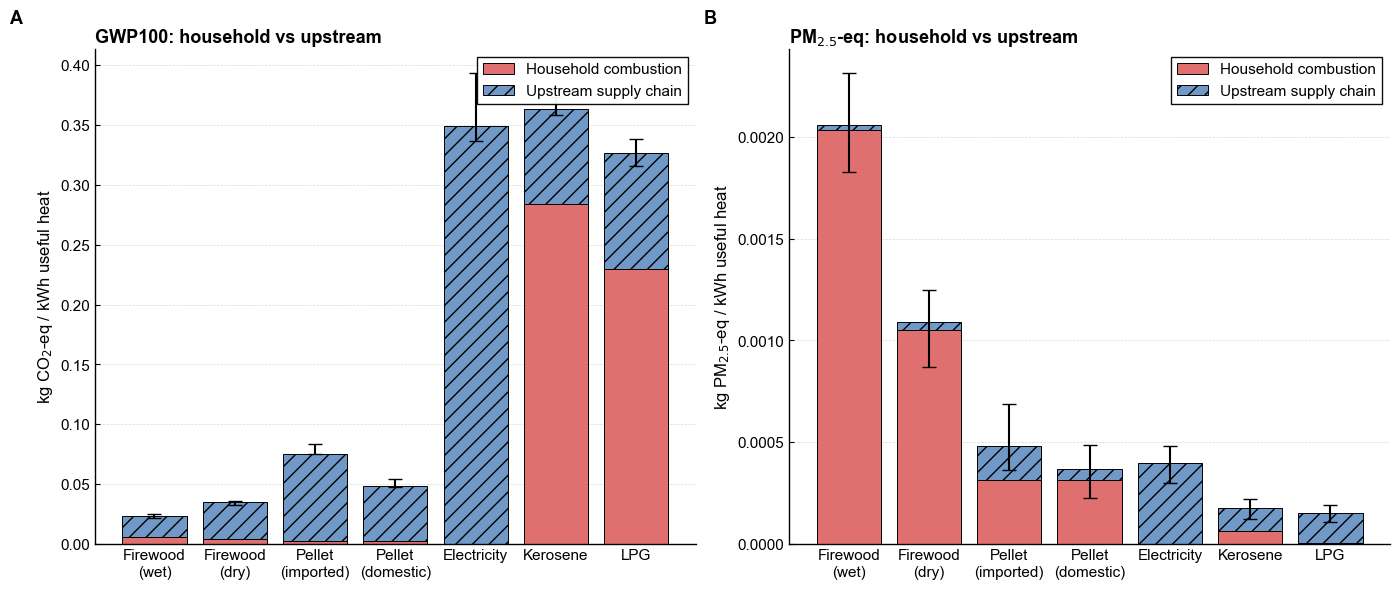


✔ Figure 2 complete — 7 technologies


In [7]:
# =============================================================================
# FIGURE 2 — HOUSEHOLD vs UPSTREAM DECOMPOSITION
# =============================================================================
# Output: FIGURE_2_hh_upstream_split.pdf / .png
#
# Two panels:
#   A) GWP100: household (red) + upstream (blue), 7 technologies
#   B) PM2.5-eq: same decomposition
#
# Data source: df_lca (scenario-level results with hh/upstream split).
# MC uncertainty from df_mc_summary (p5/p95 percentiles).
# =============================================================================

print("=" * 100)
print("FIGURE 2 — HOUSEHOLD vs UPSTREAM DECOMPOSITION (7 technologies)")
print("=" * 100)

lkp7 = df_lca.set_index("scenario")
mc7  = df_mc_summary.set_index("scenario")

# Print available MC columns for reference
print("MC summary columns:", df_mc_summary.columns.tolist())

bridge_order = ["firewood_wet", "firewood_dry", "pellet_imported",
                "pellet_domestic", "electricity", "kerosene", "lpg"]
bridge_labels = [
    "Firewood\n(wet)", "Firewood\n(dry)",
    "Pellet\n(imported)", "Pellet\n(domestic)",
    "Electricity", "Kerosene", "LPG",
]
xb = np.arange(len(bridge_order))

FS_TICK  = 11
FS_AXIS  = 12
FS_TITLE = 13
FS_LEG   = 11

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
add_panel_labels(axes)

# ── PANEL A: GWP ──────────────────────────────────────────────────────────────
ax = axes[0]
hh_gwp  = np.array([float(lkp7.loc[t, "GWP_household"]) for t in bridge_order])
up_gwp  = np.array([float(lkp7.loc[t, "GWP_upstream"])  for t in bridge_order])
tot_gwp = hh_gwp + up_gwp
p5_gwp  = np.array([float(mc7.loc[t, "GWP_p5"])  for t in bridge_order])
p95_gwp = np.array([float(mc7.loc[t, "GWP_p95"]) for t in bridge_order])
err_gwp = np.vstack([np.maximum(tot_gwp - p5_gwp, 0),
                     np.maximum(p95_gwp - tot_gwp, 0)])

ax.bar(xb, hh_gwp, color=COLORS_SPLIT["household"], edgecolor="black",
       lw=0.7, label="Household combustion")
ax.bar(xb, up_gwp, bottom=hh_gwp, color=COLORS_SPLIT["upstream"],
       edgecolor="black", lw=0.7, hatch="//", label="Upstream supply chain")
ax.errorbar(xb, tot_gwp, yerr=err_gwp, fmt="none",
            ecolor="black", elinewidth=1.5, capsize=5, zorder=5)
ax.set_xticks(xb)
ax.set_xticklabels(bridge_labels, ha="center", fontsize=FS_TICK)
ax.set_ylabel("kg CO$_{2}$-eq / kWh useful heat", fontsize=FS_AXIS)
ax.set_title("GWP100: household vs upstream", fontsize=FS_TITLE,
             fontweight="bold", loc="left", pad=5)
ax.legend(frameon=True, fontsize=FS_LEG, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── PANEL B: PM2.5 ────────────────────────────────────────────────────────────
ax = axes[1]
hh_pm  = np.array([float(lkp7.loc[t, "PM25eq_household"]) for t in bridge_order])
up_pm  = np.array([float(lkp7.loc[t, "PM25eq_upstream"])  for t in bridge_order])
tot_pm = hh_pm + up_pm

# PM25 MC column name: try common variants
_mc_cols = df_mc_summary.columns.tolist()
_p5_col  = next((c for c in _mc_cols if "PM" in c and "p5"  in c and "p95" not in c), None)
_p95_col = next((c for c in _mc_cols if "PM" in c and "p95" in c), None)

if _p5_col and _p95_col:
    p5_pm  = np.array([float(mc7.loc[t, _p5_col])  for t in bridge_order])
    p95_pm = np.array([float(mc7.loc[t, _p95_col]) for t in bridge_order])
    err_pm = np.vstack([np.maximum(tot_pm - p5_pm, 0),
                        np.maximum(p95_pm - tot_pm, 0)])
    print(f"PM25 MC columns used: {_p5_col}, {_p95_col}")
else:
    # No MC available for PM25 — skip error bars
    err_pm = None
    print("PM25 MC columns not found — error bars omitted")

ax.bar(xb, hh_pm, color=COLORS_SPLIT["household"], edgecolor="black",
       lw=0.7, label="Household combustion")
ax.bar(xb, up_pm, bottom=hh_pm, color=COLORS_SPLIT["upstream"],
       edgecolor="black", lw=0.7, hatch="//", label="Upstream supply chain")
if err_pm is not None:
    ax.errorbar(xb, tot_pm, yerr=err_pm, fmt="none",
                ecolor="black", elinewidth=1.5, capsize=5, zorder=5)
ax.set_xticks(xb)
ax.set_xticklabels(bridge_labels, ha="center", fontsize=FS_TICK)
ax.set_ylabel("kg PM$_{2.5}$-eq / kWh useful heat", fontsize=FS_AXIS)
ax.set_title("PM$_{2.5}$-eq: household vs upstream", fontsize=FS_TITLE,
             fontweight="bold", loc="left", pad=5)
ax.legend(frameon=True, fontsize=FS_LEG, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_figure(fig, "FIGURE_2_hh_upstream_split")
plt.show()
print("\n✔ Figure 2 complete — 7 technologies")

---
## Part II — PDA policy analysis

Data loading, emissions bridge, and policy figures.


In [8]:
# CELL 10 — PDA DATA LOADING
# Reads 6 sheets from AssumptionsLCAPDA_updated.xlsx into DataFrames.

# =============================================================================
# CELL 9 — PDA DATA LOADING
# =============================================================================

print("=" * 100)
print("CELL 9 — PDA DATA LOADING")
print("=" * 100)


def _rs(sheet):
    df = pd.read_excel(ASSUMPTIONS_FILE, sheet_name=sheet)
    df.columns = [str(c).strip() for c in df.columns]
    return df


df_households      = _rs("households_pda")
df_baseline_wood   = _rs("baseline_wood_stock_pda")
df_tech_transition = _rs("technology_transition_pda")
df_demand          = _rs("climatic_demand_pda")
df_cost_region     = _rs("pda_costs_region")
df_cost_central    = _rs("pda_cost_central")

for k, df in {
    "households_pda": df_households,
    "baseline_wood_stock_pda": df_baseline_wood,
    "technology_transition_pda": df_tech_transition,
    "climatic_demand_pda": df_demand,
    "pda_costs_region": df_cost_region,
    "pda_cost_central": df_cost_central,
}.items():
    print(f"  ✔ {k:<30s} {df.shape}")

TECH_MAP_PDA = {"Electricity":"electricity","Gas":"gas","Kerosene":"kerosene",
                "Firewood":"firewood","Pellets":"pellet"}
df_tech_transition["technology"] = df_tech_transition["technology"].replace(TECH_MAP_PDA)

REPLACEMENT_TECHS = ["electricity","gas","kerosene","pellet"]
YEARS = list(range(2018, 2025))

PDA_ORDER = [
    "Valle Central de O'Higgins","Valle Central de Curicó",
    "Talca y Maule","Chillán y Chillán Viejo","Concepción Metropolitano",
    "Los Ángeles","Temuco y Padre Las Casas","Valdivia","Osorno","Coyhaique",
]

print(f"\n✔ Cell 9 complete — {df_tech_transition['pda_name'].nunique()} PDAs loaded")

CELL 9 — PDA DATA LOADING
  ✔ households_pda                 (10, 9)
  ✔ baseline_wood_stock_pda        (70, 10)
  ✔ technology_transition_pda      (238, 5)
  ✔ climatic_demand_pda            (10, 10)
  ✔ pda_costs_region               (56, 3)
  ✔ pda_cost_central               (6, 2)

✔ Cell 9 complete — 10 PDAs loaded


In [9]:
# =============================================================================
# DATA PIPELINE — FIREWOOD STOCK TRANSITION
# =============================================================================
# Computes df_transition, national_repl_cum, ep_ns, ep_sn, PDA_COLOR_MAP.
# Required by Figure 1 panels C and D.
# Run this cell BEFORE Figure 1 if running cells out of order.
# =============================================================================

# =============================================================================
# APPENDIX A1 — FIREWOOD STOCK TRANSITION (2018–2024)
# =============================================================================
# Output: APPENDIX_A1_firewood_transition.pdf / .png
#
# Two panels:
#   A) Cumulative subsidised replacements by technology — stacked bars
#   B) Each zone's share of national firewood removal — 100% stacked area
#      Ordered SOUTH (bottom) to NORTH (top) in both figure and legend.
#
# Ordering logic for panel B:
#   PDA_ORDER runs north-to-south (O'Higgins → Coyhaique).
#   We REVERSE it so that the southernmost zone (Coyhaique) is at the
#   BOTTOM of the stackplot and the northernmost (O'Higgins) is at the TOP.
#   The legend is also reversed so that the topmost visual layer (O'Higgins,
#   north) appears first — giving a clean north-to-south read top-to-bottom.
# =============================================================================

print("=" * 100)
print("APPENDIX A1 — FIREWOOD STOCK TRANSITION (2-panel version)")
print("=" * 100)

# ─── BUILD TRANSITION TABLE ───────────────────────────────────────────────────
df_fw = df_baseline_wood[["pda_name","year","baseline_wood_stoves_central"]].copy()
df_fw = df_fw.rename(columns={"baseline_wood_stoves_central":"baseline_firewood_central"})

df_repl = (
    df_tech_transition[df_tech_transition["technology"].isin(REPLACEMENT_TECHS)]
    .groupby(["pda_name","year","technology"], as_index=False)["units_installed"].sum()
    .sort_values(["pda_name","technology","year"])
)
df_repl["cum_units_installed"] = df_repl.groupby(
    ["pda_name","technology"])["units_installed"].cumsum()

df_ann_w = (df_repl.pivot_table(index=["pda_name","year"], columns="technology",
             values="units_installed", aggfunc="sum", fill_value=0).reset_index())
df_ann_w.columns.name = None
df_cum_w = (df_repl.pivot_table(index=["pda_name","year"], columns="technology",
             values="cum_units_installed", aggfunc="sum", fill_value=0).reset_index())
df_cum_w.columns.name = None

for t in REPLACEMENT_TECHS:
    if t not in df_ann_w.columns: df_ann_w[t] = 0
    if t not in df_cum_w.columns: df_cum_w[t] = 0

df_cum_w["cum_replacements_total"] = df_cum_w[REPLACEMENT_TECHS].sum(axis=1)
df_ann_w = df_ann_w.rename(columns={t: f"{t}_annual" for t in REPLACEMENT_TECHS})
df_cum_w = df_cum_w.rename(columns={t: f"{t}_cum"    for t in REPLACEMENT_TECHS})

df_transition = (
    df_fw.merge(df_ann_w, on=["pda_name","year"], how="left")
         .merge(df_cum_w,  on=["pda_name","year"], how="left")
)
fill_cols = ([f"{t}_annual" for t in REPLACEMENT_TECHS] +
             [f"{t}_cum"    for t in REPLACEMENT_TECHS] + ["cum_replacements_total"])
for c in fill_cols:
    if c not in df_transition.columns: df_transition[c] = 0
    df_transition[c] = df_transition[c].fillna(0)

df_transition["firewood_removed_policy"]   = df_transition["cum_replacements_total"]
df_transition["firewood_remaining_policy"] = (
    df_transition["baseline_firewood_central"] - df_transition["firewood_removed_policy"]
).clip(lower=0)
df_transition["pct_removed"] = np.where(
    df_transition["baseline_firewood_central"] > 0,
    100 * df_transition["firewood_removed_policy"] / df_transition["baseline_firewood_central"],
    np.nan
)

national_transition = df_transition.groupby("year", as_index=False)[[
    "baseline_firewood_central","firewood_removed_policy","firewood_remaining_policy"
]].sum()
national_repl_cum = df_transition.groupby("year", as_index=False)[
    [f"{t}_cum" for t in REPLACEMENT_TECHS]].sum()
national_repl_cum["cum_replacements_total"] = national_repl_cum[
    [f"{t}_cum" for t in REPLACEMENT_TECHS]].sum(axis=1)

print("National transition summary:")
print(national_transition)

# ─── COLOURS AND LABELS ───────────────────────────────────────────────────────
TECH_COLORS_PDA = {"electricity": COLORS_TECH["electricity"],
                   "gas":         COLORS_TECH["lpg"],
                   "kerosene":    COLORS_TECH["kerosene"],
                   "pellet":      COLORS_TECH["pellet_domestic"]}
TECH_LABELS_PDA = {"electricity": "Electricity", "gas": "Gas (LPG)",
                   "kerosene": "Kerosene", "pellet": "Pellet"}

# ─── PDA ORDER FOR PANEL B ────────────────────────────────────────────────────
# PDA_ORDER = north-to-south (O'Higgins first, Coyhaique last).
# We REVERSE it so the stackplot (which stacks bottom-to-top) places
# the southernmost zone (Coyhaique) at the BOTTOM and northernmost at TOP.
# This gives a south-at-bottom / north-at-top layout, matching a map orientation.
pda_available = df_transition["pda_name"].unique().tolist()
ep_ns  = [p for p in PDA_ORDER if p in pda_available]   # north-to-south
ep_sn  = list(reversed(ep_ns))                           # south-to-north = stack order

# Short display labels
def _short(name):
    parts = name.replace("Valle Central de ", "").replace("y ", "").split()
    return parts[-1] if parts else name

cmap_pdas = plt.cm.get_cmap("tab10", len(ep_ns))
# Assign colours in north-to-south order so colour is consistent with N-S identity
PDA_COLOR_MAP = {p: cmap_pdas(i) for i, p in enumerate(ep_ns)}

# ─── FIGURE: 2 panels ─────────────────────────────────────────────────────────

print('\n✔ df_transition ready for Figure 1 panels C and D')


APPENDIX A1 — FIREWOOD STOCK TRANSITION (2-panel version)
National transition summary:
   year  baseline_firewood_central  firewood_removed_policy  \
0  2018                614205.9585                     3999   
1  2019                625633.6205                    16246   
2  2020                637063.0325                    25899   
3  2021                648490.6345                    41358   
4  2022                659920.1465                    47061   
5  2023                671347.7085                    51863   
6  2024                682777.2205                    56224   

   firewood_remaining_policy  
0                610206.9585  
1                609387.6205  
2                611164.0325  
3                607132.6345  
4                612859.1465  
5                619484.7085  
6                626553.2205  

✔ df_transition ready for Figure 1 panels C and D


C:\Users\uribep_a\AppData\Local\Temp\ipykernel_16308\1407574350.py:111: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_pdas = plt.cm.get_cmap("tab10", len(ep_ns))


FIGURE 1 — POLICY AND AIR-QUALITY CONTEXT (4 panels)


C:\Users\uribep_a\AppData\Local\Temp\ipykernel_16308\3369869651.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_pdas     = plt.cm.get_cmap("tab10", len(ep_ns))


  ✔ FIGURE_1_context.pdf
  ✔ FIGURE_1_context.png


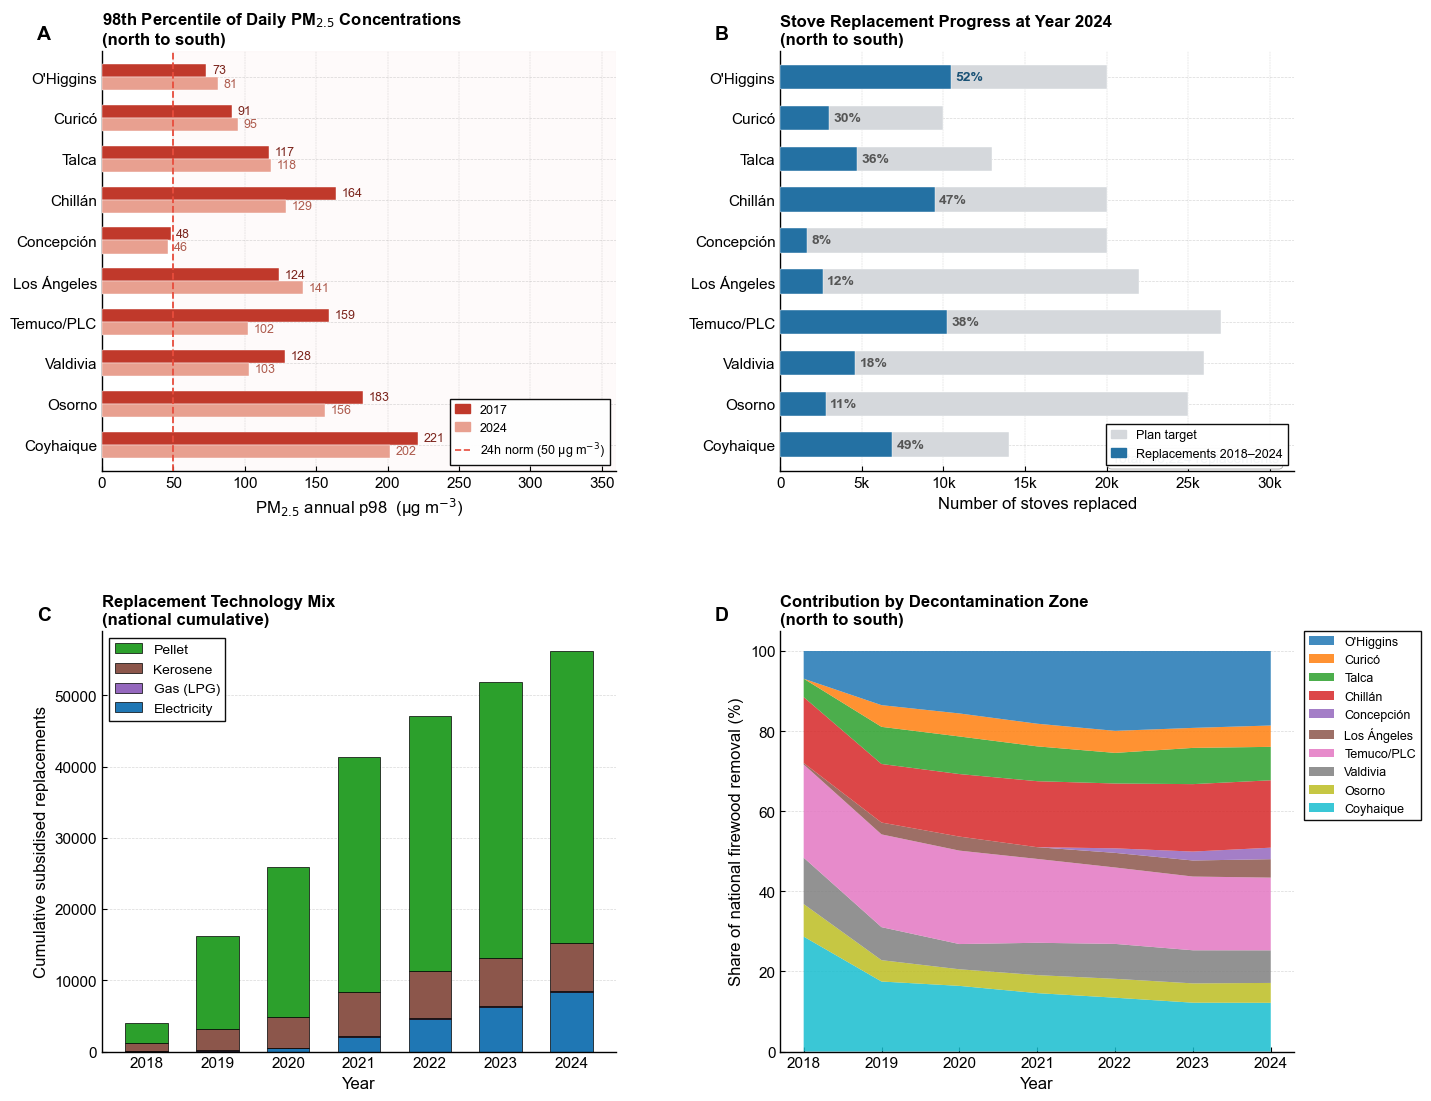


✔ Figure 1 complete — 4 panels — 56,224 total replacements


In [10]:
# =============================================================================
# FIGURE 1 — POLICY AND AIR-QUALITY CONTEXT (4 panels)
# =============================================================================
# Output: FIGURE_1_context.pdf / .png
#
# Four panels in a 2x2 layout:
#   A) PM2.5 p98 per zone, 2017 vs 2024 — the air-quality problem
#   B) Cumulative stove replacements vs plan target — the policy scale
#   C) Cumulative replacements by technology (stacked bars) — the tech mix
#   D) Zone share of national firewood removal (stacked area, S→N)
#
# Requires: df_transition, national_repl_cum, PDA_ORDER, REPLACEMENT_TECHS
# from the data pipeline cell. Run PDA data loading + data pipeline first.
# No figure caption text embedded — caption goes in LaTeX.
# =============================================================================

print("=" * 100)
print("FIGURE 1 — POLICY AND AIR-QUALITY CONTEXT (4 panels)")
print("=" * 100)

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ─── ZONE ORDER N→S ───────────────────────────────────────────────────────────
_PDA_ORDER_FIG1 = [
    "Valle Central de O'Higgins",
    "Valle Central de Curicó",
    "Talca y Maule",
    "Chillán y Chillán Viejo",
    "Concepción Metropolitano",
    "Los Ángeles",
    "Temuco y Padre Las Casas",
    "Valdivia",
    "Osorno",
    "Coyhaique",
]

# ─── PM2.5 DATA — SINIA 2025 ──────────────────────────────────────────────────
PM25_DATA = {
    "Valle Central de O'Higgins":  {"label": "O'Higgins",   "pm_2017":  73, "pm_2024":  81},
    "Valle Central de Curicó":     {"label": "Curicó",      "pm_2017":  91, "pm_2024":  95},
    "Talca y Maule":               {"label": "Talca",       "pm_2017": 117, "pm_2024": 118},
    "Chillán y Chillán Viejo":     {"label": "Chillán",     "pm_2017": 164, "pm_2024": 129},
    "Concepción Metropolitano":    {"label": "Concepción",  "pm_2017":  48, "pm_2024":  46},
    "Los Ángeles":                 {"label": "Los Ángeles", "pm_2017": 124, "pm_2024": 141},
    "Temuco y Padre Las Casas":    {"label": "Temuco/PLC",  "pm_2017": 159, "pm_2024": 102},
    "Valdivia":                    {"label": "Valdivia",    "pm_2017": 128, "pm_2024": 103},
    "Osorno":                      {"label": "Osorno",      "pm_2017": 183, "pm_2024": 156},
    "Coyhaique":                   {"label": "Coyhaique",   "pm_2017": 221, "pm_2024": 202},
}

# ─── PDA PROGRESS DATA — MMA registry 2018–2024 ───────────────────────────────
PDA_PROGRESS = {
    "Valle Central de O'Higgins":  {"repl": 10453, "target": 20000},
    "Valle Central de Curicó":     {"repl":  2997, "target": 10000},
    "Talca y Maule":               {"repl":  4692, "target": 13000},
    "Chillán y Chillán Viejo":     {"repl":  9461, "target": 20000},
    "Concepción Metropolitano":    {"repl":  1615, "target": 20000},
    "Los Ángeles":                 {"repl":  2589, "target": 22000},
    "Temuco y Padre Las Casas":    {"repl": 10205, "target": 27000},
    "Valdivia":                    {"repl":  4575, "target": 26000},
    "Osorno":                      {"repl":  2790, "target": 25000},
    "Coyhaique":                   {"repl":  6847, "target": 14000},
}

# ─── DERIVED ARRAYS ───────────────────────────────────────────────────────────
ZONE_LABELS  = [PM25_DATA[p]["label"]   for p in _PDA_ORDER_FIG1]
PM25_2017    = [PM25_DATA[p]["pm_2017"] for p in _PDA_ORDER_FIG1]
PM25_2024    = [PM25_DATA[p]["pm_2024"] for p in _PDA_ORDER_FIG1]
REPLACEMENTS = [PDA_PROGRESS[p]["repl"]   for p in _PDA_ORDER_FIG1]
TARGETS      = [PDA_PROGRESS[p]["target"] for p in _PDA_ORDER_FIG1]
PCT_DONE     = [r / t * 100 for r, t in zip(REPLACEMENTS, TARGETS)]

# ─── COLOURS ──────────────────────────────────────────────────────────────────
C_2017   = "#c0392b"
C_2024   = "#e8a090"
C_REPL   = "#2471a3"
C_TARGET = "#d5d8dc"
C_NORM   = "#e74c3c"

TECH_COLORS_PDA = {"electricity": COLORS_TECH["electricity"],
                   "gas":         COLORS_TECH["lpg"],
                   "kerosene":    COLORS_TECH["kerosene"],
                   "pellet":      COLORS_TECH["pellet_domestic"]}
TECH_LABELS_PDA = {"electricity": "Electricity", "gas": "Gas (LPG)",
                   "kerosene": "Kerosene", "pellet": "Pellet"}

n = len(_PDA_ORDER_FIG1)
y = np.arange(n)

# ─── PDA ORDER FOR PANEL D ────────────────────────────────────────────────────
pda_available = df_transition["pda_name"].unique().tolist()
ep_ns = [p for p in PDA_ORDER if p in pda_available]
ep_sn = list(reversed(ep_ns))   # south-to-north = stack order

def _short(name):
    """Return a clean short label for legend display."""
    _labels = {
        "Valle Central de O'Higgins": "O'Higgins",
        "Valle Central de Curicó":    "Curicó",
        "Talca y Maule":              "Talca",
        "Chillán y Chillán Viejo":   "Chillán",
        "Concepción Metropolitano":   "Concepción",
        "Los Ángeles":                "Los Ángeles",
        "Temuco y Padre Las Casas":   "Temuco/PLC",
        "Valdivia":                   "Valdivia",
        "Osorno":                     "Osorno",
        "Coyhaique":                  "Coyhaique",
    }
    return _labels.get(name, name)

cmap_pdas     = plt.cm.get_cmap("tab10", len(ep_ns))
PDA_COLOR_MAP = {p: cmap_pdas(i) for i, p in enumerate(ep_ns)}

# ─── NATIONAL CUMULATIVE REPLACEMENTS BY TECHNOLOGY (for panel C) ─────────────
national_repl_cum = df_transition.groupby("year", as_index=False)[
    [f"{t}_cum" for t in REPLACEMENT_TECHS]].sum()

# ─── FIGURE: 2 rows × 2 columns ──────────────────────────────────────────────
# Panel D needs space for external legend — use constrained_layout=False
# and manually adjust right margin after drawing
fig, axes = plt.subplots(2, 2, figsize=(16, 13),
                         gridspec_kw={"hspace": 0.38, "wspace": 0.32})

# Panel labels A, B, C, D added via add_panel_labels — BUT titles will NOT
# repeat the letter, so we pass custom offset to position labels clearly
_axlist = axes.flatten()
for ax, lbl in zip(_axlist, ["A", "B", "C", "D"]):
    ax.text(-0.10, 1.06, lbl, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="right")

# ── PANEL A: PM2.5 — 2017 bar ABOVE 2024 bar ─────────────────────────────────
# With ax.invert_yaxis(): lower y-value → top of chart.
# y - bh/2 < y + bh/2  →  y-bh/2 plots higher (above) in the inverted axis.
# So: 2017 → y - bh/2 (appears above), 2024 → y + bh/2 (appears below).
ax = axes[0, 0]
bh = 0.32
ax.barh(y - bh/2, PM25_2017, height=bh, color=C_2017,
        edgecolor="white", lw=0.3, label="2017", zorder=3)
ax.barh(y + bh/2, PM25_2024, height=bh, color=C_2024,
        edgecolor="white", lw=0.3, label="2024", zorder=3)
ax.axvline(50, color=C_NORM, lw=1.3, ls="--", zorder=4)
ax.axvspan(50, 360, color="#fdecea", alpha=0.22, zorder=0)

for i, (v17, v24) in enumerate(zip(PM25_2017, PM25_2024)):
    ax.text(v17 + 4, i - bh/2, str(v17), va="center", ha="left",
            fontsize=9, color="#7b241c")
    ax.text(v24 + 4, i + bh/2, str(v24), va="center", ha="left",
            fontsize=9, color="#a04030", alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(ZONE_LABELS, fontsize=11)
ax.set_xlabel("PM$_{2.5}$ annual p98  (µg m$^{-3}$)", fontsize=12)
ax.set_xlim(0, 360)
ax.set_ylim(-0.65, n - 0.35)
ax.invert_yaxis()
ax.grid(axis="x", color="gray", lw=0.35, alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
leg17  = mpatches.Patch(color=C_2017, label="2017")
leg24  = mpatches.Patch(color=C_2024, label="2024")
legnrm = mlines.Line2D([0], [0], color=C_NORM, ls="--", lw=1.2,
                       label="24h norm (50 µg m$^{-3}$)")
ax.legend(handles=[leg17, leg24, legnrm], fontsize=9,
          handlelength=1.2, loc="lower right")
ax.set_title("98th Percentile of Daily PM$_{2.5}$ Concentrations\n"
             "(north to south)", fontsize=12, fontweight="bold",
             loc="left", pad=5)

# ── PANEL B: PROGRAMME PROGRESS ───────────────────────────────────────────────
ax = axes[0, 1]
ax.barh(y, TARGETS,      height=0.6, color=C_TARGET,
        edgecolor="white", lw=0.3, label="Plan target", zorder=2)
ax.barh(y, REPLACEMENTS, height=0.6, color=C_REPL,
        edgecolor="white", lw=0.3, label="Replacements 2018–2024", zorder=3)
for i, (r, pct) in enumerate(zip(REPLACEMENTS, PCT_DONE)):
    col = "#1a5276" if pct >= 50 else "#555555"
    ax.text(r + 280, i, f"{pct:.0f}%", va="center", ha="left",
            fontsize=10, color=col, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(ZONE_LABELS, fontsize=11)
ax.set_xlabel("Number of stoves replaced", fontsize=12)
ax.set_xlim(0, 31500)
ax.set_ylim(-0.65, n - 0.35)
ax.invert_yaxis()
ax.grid(axis="x", color="gray", lw=0.35, alpha=0.35, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else "0"))
tgt_p  = mpatches.Patch(color=C_TARGET, label="Plan target")
repl_p = mpatches.Patch(color=C_REPL,   label="Replacements 2018–2024")
ax.legend(handles=[tgt_p, repl_p], fontsize=9,
          handlelength=1.2, loc="lower right")
ax.set_title("Stove Replacement Progress at Year 2024\n"
             "(north to south)", fontsize=12, fontweight="bold",
             loc="left", pad=5)
ax.text(0.97, 0.015, f"Total: {sum(REPLACEMENTS):,} replacements",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        color="#1a5276",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#aaa", lw=0.6))

# ── PANEL C: CUMULATIVE REPLACEMENTS BY TECHNOLOGY ────────────────────────────
# Bar width harmonised with panel B: use width=0.6 (same visual weight as
# the horizontal bars in B which have height=0.6)
ax = axes[1, 0]
bottom = np.zeros(len(national_repl_cum))
years  = national_repl_cum["year"].values
for t in REPLACEMENT_TECHS:
    vals = national_repl_cum[f"{t}_cum"].values
    ax.bar(years, vals, bottom=bottom, width=0.6,
           color=TECH_COLORS_PDA[t], edgecolor="black", lw=0.5,
           label=TECH_LABELS_PDA[t])
    bottom += vals
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative subsidised replacements", fontsize=12)
ax.set_title("Replacement Technology Mix\n"
             "(national cumulative)", fontsize=12, fontweight="bold",
             loc="left", pad=5)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
_h, _l = ax.get_legend_handles_labels()
ax.legend(_h[::-1], _l[::-1], fontsize=10, frameon=True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── PANEL D: ZONE CONTRIBUTION — legend outside right ─────────────────────────
ax = axes[1, 1]
pda_rem = (df_transition.groupby(["year", "pda_name"])["firewood_removed_policy"]
           .sum().unstack(fill_value=0))
ep_plot = [p for p in ep_sn if p in pda_rem.columns]
pda_rem = pda_rem[ep_plot]
pda_pct = pda_rem.div(pda_rem.sum(axis=1), axis=0).multiply(100)
ax.stackplot(pda_pct.index.values,
             [pda_pct[p].values for p in ep_plot],
             labels=[_short(p) for p in ep_plot],
             colors=[PDA_COLOR_MAP[p] for p in ep_plot],
             alpha=0.85)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Share of national firewood removal (%)", fontsize=12)
ax.set_title("Contribution by Decontamination Zone\n"
             "(north to south)", fontsize=12,
             fontweight="bold", loc="left", pad=5)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend outside the axes, to the right
_h, _l = ax.get_legend_handles_labels()
ax.legend(_h[::-1], _l[::-1], fontsize=9, frameon=True,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, ncol=1)

# Adjust right margin so external legend fits without clipping
fig.subplots_adjust(right=0.87)

plt.savefig(OUTPUT_DIR / "FIGURE_1_context.pdf", dpi=600, bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "FIGURE_1_context.png", dpi=300, bbox_inches="tight")
print("  ✔ FIGURE_1_context.pdf")
print("  ✔ FIGURE_1_context.png")
plt.show()
print(f"\n✔ Figure 1 complete — 4 panels — {sum(REPLACEMENTS):,} total replacements")

In [11]:
# CELL 12 — EMISSIONS BRIDGE (annual PM2.5 + CO2, both scenarios)
# Computes df_emissions and national_emissions used by downstream figure cells.

# CELL 11 — ANNUAL EMISSIONS BRIDGE (baseline vs policy)

print("=" * 100)
print("CELL 11 — ANNUAL EMISSIONS BRIDGE")
print("=" * 100)

SCENARIO_MAP_PDA = {"electricity":"electricity","gas":"gas","kerosene":"kerosene","pellet":"pellet"}

df_bridge = lca_bridge_central.copy()
for c in ["CO2_total_kg_per_kWh","PM25eq_kg_per_kWh"]:
    df_bridge[c] = pd.to_numeric(df_bridge[c], errors="coerce")

co2_lca = df_bridge.set_index("technology")["CO2_total_kg_per_kWh"].to_dict()
pm_lca  = df_bridge.set_index("technology")["PM25eq_kg_per_kWh"].to_dict()
co2_p5  = df_bridge.set_index("technology")["CO2_total_p5"].to_dict()
co2_p95 = df_bridge.set_index("technology")["CO2_total_p95"].to_dict()
pm_p5   = df_bridge.set_index("technology")["PM25eq_p5"].to_dict()
pm_p95  = df_bridge.set_index("technology")["PM25eq_p95"].to_dict()

df_demand["demand_central_kWh_hh_year"] = pd.to_numeric(
    df_demand["demand_central_kWh_hh_year"], errors="coerce")
dem_lkp = df_demand.set_index("pda_name")["demand_central_kWh_hh_year"].to_dict()

emit_rows = []
for _, row in df_transition.iterrows():
    pda  = row["pda_name"]
    dem  = dem_lkp.get(pda, USEFUL_HEAT_KWH_PER_STOVE)
    fw_b = row["baseline_firewood_central"]
    fw_p = row["firewood_remaining_policy"]

    co2_base = fw_b * dem * co2_lca["firewood"]
    pm_base  = fw_b * dem * pm_lca["firewood"]
    co2_pol  = fw_p * dem * co2_lca["firewood"]
    pm_pol   = fw_p * dem * pm_lca["firewood"]
    for t in REPLACEMENT_TECHS:
        bt = SCENARIO_MAP_PDA.get(t, t)
        stock = row[f"{t}_cum"]
        co2_pol += stock * dem * co2_lca.get(bt, 0.0)
        pm_pol  += stock * dem * pm_lca.get(bt,  0.0)

    emit_rows.append({
        "pda_name": pda, "year": row["year"],
        "CO2_baseline_tpa":  co2_base / 1000,
        "CO2_policy_tpa":    co2_pol  / 1000,
        "CO2_avoided_tpa":   (co2_base - co2_pol) / 1000,
        "PM_baseline_kg":    pm_base,
        "PM_policy_kg":      pm_pol,
        "PM_avoided_kg":     pm_base - pm_pol,
    })

df_emissions = pd.DataFrame(emit_rows)
national_emissions = df_emissions.groupby("year", as_index=False)[[
    "CO2_baseline_tpa","CO2_policy_tpa","CO2_avoided_tpa",
    "PM_baseline_kg","PM_policy_kg","PM_avoided_kg",
]].sum()

# MC bands for national policy emissions
nat_mc_rows = []
for _, row in national_emissions.iterrows():
    yr = row["year"]
    yt = df_transition[df_transition["year"] == yr]
    co2p5=co2p95=pmp5=pmp95=0.0
    for _, tr in yt.iterrows():
        dem = dem_lkp.get(tr["pda_name"], USEFUL_HEAT_KWH_PER_STOVE)
        fw  = tr["firewood_remaining_policy"]
        co2p5  += fw * dem * co2_p5.get("firewood", co2_lca["firewood"])
        co2p95 += fw * dem * co2_p95.get("firewood", co2_lca["firewood"])
        pmp5   += fw * dem * pm_p5.get("firewood",   pm_lca["firewood"])
        pmp95  += fw * dem * pm_p95.get("firewood",  pm_lca["firewood"])
        for t in REPLACEMENT_TECHS:
            s = tr[f"{t}_cum"]
            bt = SCENARIO_MAP_PDA.get(t, t)
            co2p5  += s * dem * co2_p5.get(bt,  co2_lca.get(bt, 0))
            co2p95 += s * dem * co2_p95.get(bt, co2_lca.get(bt, 0))
            pmp5   += s * dem * pm_p5.get(bt,   pm_lca.get(bt, 0))
            pmp95  += s * dem * pm_p95.get(bt,  pm_lca.get(bt, 0))
    nat_mc_rows.append({
        "year": yr,
        "CO2_policy_p5_t":  co2p5/1000,  "CO2_policy_p95_t":  co2p95/1000,
        "PM_policy_p5_kg":  pmp5,         "PM_policy_p95_kg":  pmp95,
    })
df_nat_mc = pd.DataFrame(nat_mc_rows)

print("National annual emissions:")
display(national_emissions.round(0))
print("\n✔ Cell 11 complete — df_emissions, national_emissions, df_nat_mc ready")

CELL 11 — ANNUAL EMISSIONS BRIDGE
National annual emissions:


,year,CO2_baseline_tpa,CO2_policy_tpa,CO2_avoided_tpa,PM_baseline_kg,PM_policy_kg,PM_avoided_kg
0,2018,53126.0,55543.0,-2417.0,4926330.0,4891114.0,35216.0
1,2019,54148.0,60361.0,-6213.0,5021153.0,4895807.0,125346.0
2,2020,55171.0,64501.0,-9330.0,5115987.0,4921147.0,194841.0
3,2021,56193.0,71581.0,-15388.0,5210799.0,4903205.0,307595.0
4,2022,57216.0,76080.0,-18864.0,5305634.0,4958744.0,346890.0
5,2023,58239.0,79674.0,-21436.0,5400456.0,5022144.0,378312.0
6,2024,59261.0,83720.0,-24459.0,5495291.0,5084710.0,410581.0



✔ Cell 11 complete — df_emissions, national_emissions, df_nat_mc ready


---
## Part III — Cost-effectiveness

**Appendix A2**: annual PM₂.₅ avoided by zone (stacked area).


APPENDIX A2 — ANNUAL PM2.5 AVOIDED BY ZONE (stacked area)
pda_summary_ce (10 zones):


,pda_name,PM_avoided_total_t,total_cost_usd,cost_per_t_pm,total_replacements
0,Chillán y Chillán Viejo,303.4,2905468.3,9576.0,9461
1,Concepción Metropolitano,19.3,2905468.3,150395.4,1615
2,Coyhaique,370.6,2905468.3,7840.5,6847
3,Los Ángeles,68.7,2905468.3,42314.0,2589
4,Osorno,111.7,2905468.3,26018.1,2790
5,Talca y Maule,96.8,2905468.3,30020.3,4692
6,Temuco y Padre Las Casas,370.9,2905468.3,7833.7,10205
7,Valdivia,190.6,2905468.3,15247.5,4575
8,Valle Central de Curicó,60.3,2905468.3,48213.7,2997
9,Valle Central de O'Higgins,206.6,2905468.3,14060.1,10453


C:\Users\uribep_a\AppData\Local\Temp\ipykernel_16308\4087171086.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ce = plt.cm.get_cmap("tab10", len(ep_ns))


  ✔ APPENDIX_A2_pm25_avoided_by_zone.pdf
  ✔ APPENDIX_A2_pm25_avoided_by_zone.png


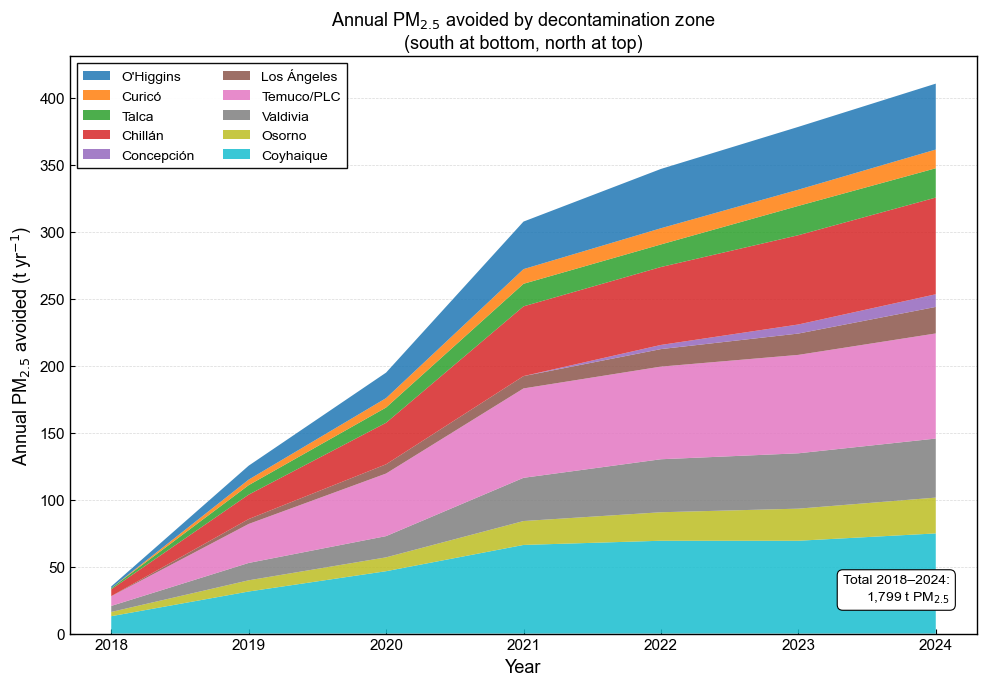


✔ pda_summary_ce ready (APPENDIX_A2 — stacked area PM2.5 avoided)


In [12]:
# =============================================================================
# APPENDIX A2 — ANNUAL PM2.5 AVOIDED BY DECONTAMINATION ZONE (2018–2024)
# =============================================================================
# Output: APPENDIX_A2_pm25_avoided_by_zone.pdf / .png
#
# Single panel: stacked area chart of annual PM2.5 avoided per zone.
# Zones ordered south-to-north in the stack (south at bottom) and
# the legend reads north-to-south (northernmost first).
#
# This figure shows WHEN each zone contributed to national PM2.5 reductions
# and how the programme ramped up over 2018–2024.
# =============================================================================

print("=" * 100)
print("APPENDIX A2 — ANNUAL PM2.5 AVOIDED BY ZONE (stacked area)")
print("=" * 100)

FX_CE = FX_CLP_PER_USD

# ─── DEMAND + PM ──────────────────────────────────────────────────────────────
df_demand["demand_central_kWh_hh_year"] = pd.to_numeric(
    df_demand["demand_central_kWh_hh_year"], errors="coerce")

pm_df = df_transition.copy().merge(
    df_demand[["pda_name","demand_central_kWh_hh_year"]], on="pda_name", how="left")
pm_df = pm_df.rename(columns={"demand_central_kWh_hh_year":"demand_kWh_hh_year"})

pm_df["PM_baseline_kg"] = (pm_df["baseline_firewood_central"]
                            * pm_df["demand_kWh_hh_year"] * pm_lca["firewood"])
pm_df["PM_policy_kg"] = (
    pm_df["firewood_remaining_policy"] * pm_df["demand_kWh_hh_year"] * pm_lca["firewood"] +
    pm_df["electricity_cum"] * pm_df["demand_kWh_hh_year"] * pm_lca["electricity"] +
    pm_df["gas_cum"]         * pm_df["demand_kWh_hh_year"] * pm_lca["gas"] +
    pm_df["kerosene_cum"]    * pm_df["demand_kWh_hh_year"] * pm_lca["kerosene"] +
    pm_df["pellet_cum"]      * pm_df["demand_kWh_hh_year"] * pm_lca["pellet"]
)
pm_df["PM_avoided_t"] = (pm_df["PM_baseline_kg"] - pm_df["PM_policy_kg"]) / 1000

# ─── COMPUTE CUMULATIVE SUMMARY (also saved for cost-effectiveness tables) ────
if "total_cost_usd" not in df_cost_region.columns:
    df_cost_region["total_cost_usd"] = (
        pd.to_numeric(df_cost_region["cost_clp"], errors="coerce") / FX_CE)
if "total_cost_usd" not in df_cost_central.columns:
    df_cost_central["total_cost_usd"] = (
        pd.to_numeric(df_cost_central["cost_clp"], errors="coerce") / FX_CE)

_cost_region_yr = df_cost_region.groupby("year", as_index=False)["total_cost_usd"].sum()
n_pdas_yr = pm_df.groupby("year")["pda_name"].nunique().to_dict()
_cost_region_yr["n_pdas"] = _cost_region_yr["year"].map(n_pdas_yr).fillna(1)
_cost_region_yr["region_per_pda_usd"] = (
    _cost_region_yr["total_cost_usd"] / _cost_region_yr["n_pdas"])

if "central_per_pda_usd" not in df_cost_central.columns:
    _n_pdas_cc = df_cost_central["year"].map(n_pdas_yr).fillna(1)
    df_cost_central["central_per_pda_usd"] = df_cost_central["total_cost_usd"] / _n_pdas_cc

pm_cost_df = pm_df[["pda_name","year","PM_avoided_t"]].merge(
    _cost_region_yr[["year","region_per_pda_usd"]], on="year", how="left"
).merge(df_cost_central[["year","central_per_pda_usd"]], on="year", how="left")
pm_cost_df["region_per_pda_usd"]  = pm_cost_df["region_per_pda_usd"].fillna(0)
pm_cost_df["central_per_pda_usd"] = pm_cost_df["central_per_pda_usd"].fillna(0)
pm_cost_df["combined_cost_usd"]   = (pm_cost_df["region_per_pda_usd"]
                                      + pm_cost_df["central_per_pda_usd"])

pda_summary_ce = pm_cost_df.groupby("pda_name", as_index=False).agg(
    PM_avoided_total_t=("PM_avoided_t",      "sum"),
    total_cost_usd    =("combined_cost_usd", "sum"),
)
pda_summary_ce["cost_per_t_pm"] = (
    pda_summary_ce["total_cost_usd"]
    / pda_summary_ce["PM_avoided_total_t"].replace(0, np.nan)
)
repl_lookup = (df_transition.groupby("pda_name")["cum_replacements_total"].max().to_dict())
pda_summary_ce["total_replacements"] = pda_summary_ce["pda_name"].map(repl_lookup).fillna(0)

print(f"pda_summary_ce ({len(pda_summary_ce)} zones):")
from IPython.display import display
display(pda_summary_ce[["pda_name","PM_avoided_total_t","total_cost_usd",
                         "cost_per_t_pm","total_replacements"]].round(1))

# ─── ZONE ORDER: south at bottom, north at top ────────────────────────────────
pda_avail = pm_df["pda_name"].unique().tolist()
ep_ns = [p for p in PDA_ORDER if p in pda_avail]   # north-to-south
ep_sn = list(reversed(ep_ns))                       # south-to-north (stack order)

def _short(name):
    """Return a clean short label for legend display."""
    _labels = {
        "Valle Central de O'Higgins": "O'Higgins",
        "Valle Central de Curicó":    "Curicó",
        "Talca y Maule":              "Talca",
        "Chillán y Chillán Viejo":   "Chillán",
        "Concepción Metropolitano":   "Concepción",
        "Los Ángeles":                "Los Ángeles",
        "Temuco y Padre Las Casas":   "Temuco/PLC",
        "Valdivia":                   "Valdivia",
        "Osorno":                     "Osorno",
        "Coyhaique":                  "Coyhaique",
    }
    return _labels.get(name, name)

cmap_ce = plt.cm.get_cmap("tab10", len(ep_ns))
PDA_COLOR_MAP_CE = {p: cmap_ce(i) for i, p in enumerate(ep_ns)}

# ─── FIGURE: single panel stacked area ───────────────────────────────────────
pm_piv = pm_df.pivot_table(index="year", columns="pda_name",
                            values="PM_avoided_t", aggfunc="sum").fillna(0)
ep_plot = [p for p in ep_sn if p in pm_piv.columns]
pm_piv  = pm_piv[ep_plot]

fig, ax = plt.subplots(figsize=(10, 7))

ax.stackplot(pm_piv.index.values,
             [pm_piv[p].values for p in ep_plot],
             labels=[_short(p) for p in ep_plot],
             colors=[PDA_COLOR_MAP_CE[p] for p in ep_plot],
             alpha=0.85)

# Annotate total avoided
total_t = pm_df["PM_avoided_t"].sum()
ax.text(0.97, 0.05,
        f"Total 2018–2024:\n{total_t:,.0f} t PM$_{{2.5}}$",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=0.8))

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Annual PM$_{2.5}$ avoided (t yr$^{-1}$)", fontsize=13)
ax.set_title("Annual PM$_{2.5}$ avoided by decontamination zone\n"
             "(south at bottom, north at top)", fontsize=13)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Reverse legend so northernmost zone appears first (north-to-south reading)
_h, _l = ax.get_legend_handles_labels()
ax.legend(_h[::-1], _l[::-1], fontsize=10, frameon=True,
          loc="upper left", ncol=2)

plt.tight_layout()
save_figure(fig, "APPENDIX_A2_pm25_avoided_by_zone")
plt.show()
print("\n✔ pda_summary_ce ready (APPENDIX_A2 — stacked area PM2.5 avoided)")


---
## Part IV — External costs and biogenic comparison

**Figure 3**: external costs both scenarios.  
**Figure 4**: biogenic scenario comparison (3 panels).


FIGURE 3 — External costs per kWh, both biogenic scenarios
  ✔ FIGURE_3_external_costs.pdf
  ✔ FIGURE_3_external_costs.png


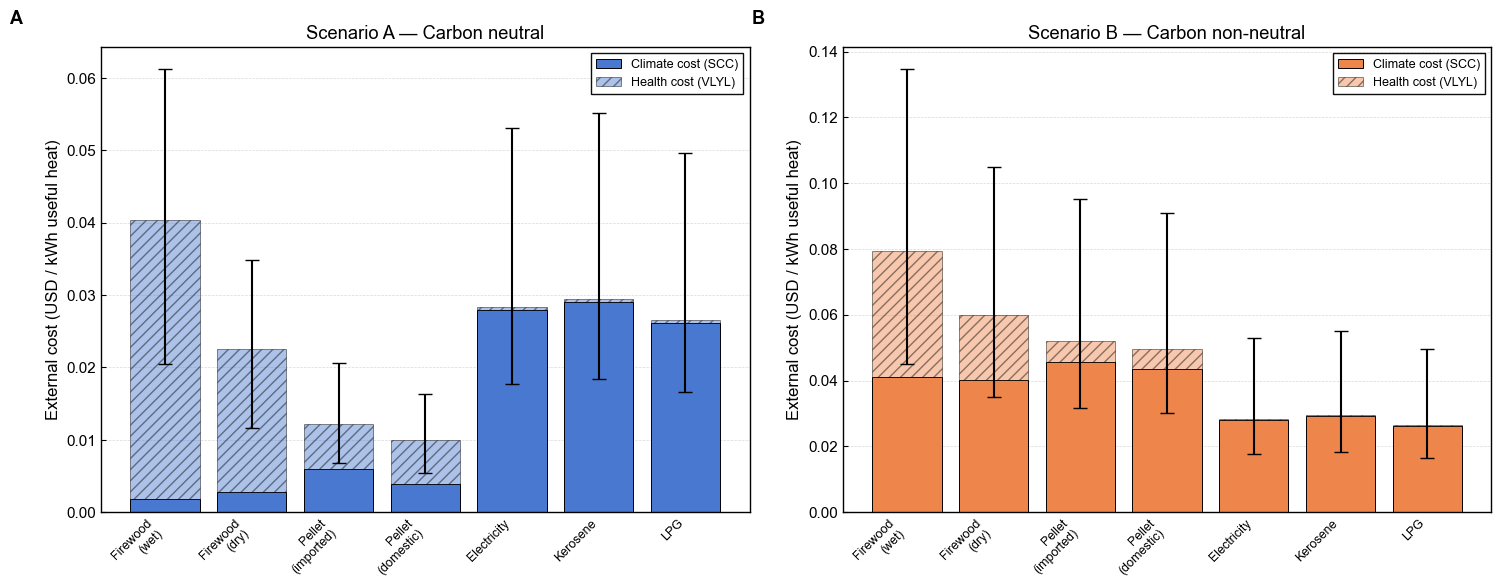


✔ Paper Fig. 4 complete
FIGURE 4 — BIOGENIC SCENARIO COMPARISON (3 panels: A, B, C)
  ✔ FIGURE_4_biogenic_comparison.pdf
  ✔ FIGURE_4_biogenic_comparison.png


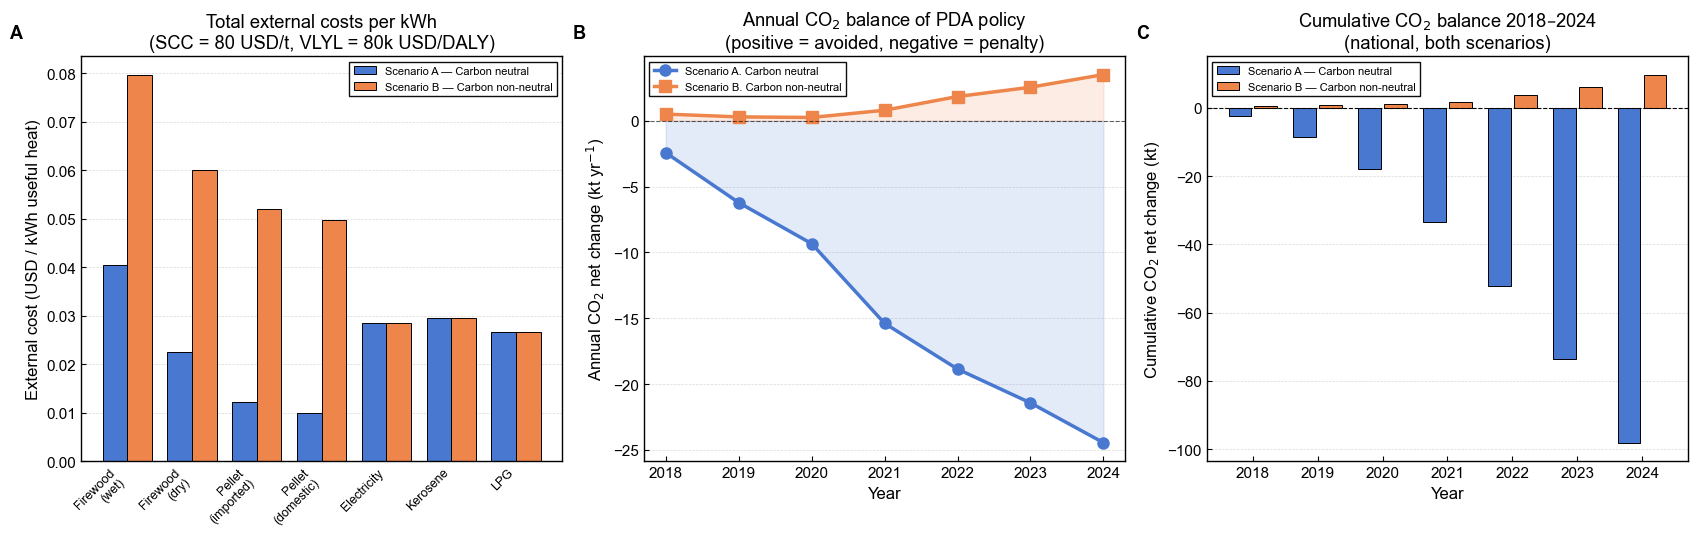


✔ Paper Fig. 5 complete (3-panel: A, B, C)


In [13]:
# =============================================================================
# FIGURE 3 — EXTERNAL COSTS PER kWh — BOTH BIOGENIC SCENARIOS
# =============================================================================
# Output: PAPER_FIG4_external_costs_both_scenarios.pdf / .png
#
# Design: grouped bars per technology, one group per scenario (A and B).
# Each bar is decomposed into climate cost (bottom) and health cost (top, hatched).
# Error bars show low/high valuation range (SCC 50-150, VLYL 40k-120k).
#
# Key message:
#   - Under Scenario A: health cost dominates for firewood; climate cost is tiny.
#   - Under Scenario B: climate cost rises sharply for biomass, reversing the
#     relative ranking vs fossil fuels.
#   - LPG/electricity/kerosene: almost entirely climate cost; health near zero.
# =============================================================================

print("FIGURE 3 — External costs per kWh, both biogenic scenarios")

def _ext_costs(df, scc=SCC_CENTRAL, vlyl=V_DALY_CENTRAL):
    """Compute external cost components for a LCA scenario dataframe."""
    return df.assign(
        climate_cost = df["GWP_total"]  * scc  / 1000,
        health_cost  = df["DALY_total"] * vlyl,
    ).assign(total_ext = lambda d: d["climate_cost"] + d["health_cost"])

ec_n  = _ext_costs(df_lca.set_index("scenario").loc[TECH_ORDER].reset_index())
ec_nn = _ext_costs(df_lca_nn.set_index("scenario").loc[TECH_ORDER].reset_index())

# Low/high bounds for error bars
ec_n_lo  = _ext_costs(df_lca.set_index("scenario").loc[TECH_ORDER].reset_index(),
                      scc=SCC_LOW,  vlyl=V_DALY_LOW)
ec_n_hi  = _ext_costs(df_lca.set_index("scenario").loc[TECH_ORDER].reset_index(),
                      scc=SCC_HIGH, vlyl=V_DALY_HIGH)
ec_nn_lo = _ext_costs(df_lca_nn.set_index("scenario").loc[TECH_ORDER].reset_index(),
                      scc=SCC_LOW,  vlyl=V_DALY_LOW)
ec_nn_hi = _ext_costs(df_lca_nn.set_index("scenario").loc[TECH_ORDER].reset_index(),
                      scc=SCC_HIGH, vlyl=V_DALY_HIGH)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
add_panel_labels(axes)
x = np.arange(len(TECH_ORDER))
labels = [TECH_LABELS[s] for s in TECH_ORDER]

for ax, ec_c, ec_lo, ec_hi, scen_label, scen_key in [
    (axes[0], ec_n,  ec_n_lo,  ec_n_hi,  "Scenario A — Carbon neutral",     "neutral"),
    (axes[1], ec_nn, ec_nn_lo, ec_nn_hi, "Scenario B — Carbon non-neutral", "non_neutral"),
]:
    ax.bar(x, ec_c["climate_cost"], color=BIOGENIC_COLORS[scen_key],
           edgecolor="black", lw=0.7, label="Climate cost (SCC)")
    ax.bar(x, ec_c["health_cost"], bottom=ec_c["climate_cost"],
           color=BIOGENIC_COLORS[scen_key], alpha=0.45, hatch="///",
           edgecolor="black", lw=0.7, label="Health cost (VLYL)")
    err = np.vstack([
        np.maximum(ec_c["total_ext"].values - ec_lo["total_ext"].values, 0),
        np.maximum(ec_hi["total_ext"].values - ec_c["total_ext"].values, 0),
    ])
    ax.errorbar(x, ec_c["total_ext"].values, yerr=err,
                fmt="none", ecolor="black", elinewidth=1.5, capsize=5, zorder=5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("External cost (USD / kWh useful heat)")
    ax.set_title(scen_label)
    ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
save_figure(fig, "FIGURE_3_external_costs")
plt.show()
print("\n✔ Paper Fig. 4 complete")


# =============================================================================
# FIGURE 4 — BIOGENIC CARBON SCENARIO COMPARISON (3 panels: A, B, C)
# =============================================================================
# Output: PAPER_FIG5_biogenic_scenario_comparison.pdf / .png
#
# Layout: 1 row x 3 panels. Panel C (scatter health vs climate with arrows)
# removed — not sufficiently clear.
#
#   A) Total external costs per kWh — grouped bars, both scenarios
#   B) Annual CO2 net balance of PDA policy, both scenarios
#   C) Cumulative CO2 net change 2018–2024, both scenarios
# =============================================================================

print("=" * 100)
print("FIGURE 4 — BIOGENIC SCENARIO COMPARISON (3 panels: A, B, C)")
print("=" * 100)

def _national_co2_net(bridge_df):
    """Sum annual CO2 net change across all PDAs under a given bridge."""
    lkp = bridge_df.set_index("technology")["CO2_total_kg_per_kWh"].to_dict()
    rows_co2 = []
    for _, tr in df_transition.iterrows():
        dem  = dem_lkp.get(tr["pda_name"], USEFUL_HEAT_KWH_PER_STOVE)
        fw_b = tr["baseline_firewood_central"]
        fw_p = tr["firewood_remaining_policy"]
        co2_b = fw_b * dem * lkp["firewood"]
        co2_p = fw_p * dem * lkp["firewood"]
        for t in REPLACEMENT_TECHS:
            bt = SCENARIO_MAP_PDA.get(t, t)
            co2_p += tr[f"{t}_cum"] * dem * lkp.get(bt, 0)
        rows_co2.append({"year": tr["year"], "CO2_net_t": (co2_b - co2_p) / 1000})
    return pd.DataFrame(rows_co2).groupby("year", as_index=False)["CO2_net_t"].sum()

nat_co2_n  = _national_co2_net(lca_bridge_central)
nat_co2_nn = _national_co2_net(lca_bridge_central_nn)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
add_panel_labels(axes)
x      = np.arange(len(TECH_ORDER))
w      = 0.38
labels = [TECH_LABELS[s] for s in TECH_ORDER]
yrs    = nat_co2_n["year"].values

# ─── PANEL A — External costs per kWh, grouped bars ──────────────────────────
ax = axes[0]
ax.bar(x - w/2, ec_n["total_ext"],  width=w,
       color=BIOGENIC_COLORS["neutral"],     edgecolor="black", lw=0.7,
       label="Scenario A — Carbon neutral")
ax.bar(x + w/2, ec_nn["total_ext"], width=w,
       color=BIOGENIC_COLORS["non_neutral"], edgecolor="black", lw=0.7,
       label="Scenario B — Carbon non-neutral")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("External cost (USD / kWh useful heat)")
ax.set_title("Total external costs per kWh\n"
             "(SCC = 80 USD/t, VLYL = 80k USD/DALY)")
ax.legend(frameon=True, fontsize=8, loc="upper right")

# ─── PANEL B — Annual CO2 net balance of PDA policy ──────────────────────────
ax = axes[1]
ax.plot(yrs, nat_co2_n["CO2_net_t"]  / 1000, color=BIOGENIC_COLORS["neutral"],
        lw=2.5, marker="o", label="Scenario A. Carbon neutral")
ax.plot(yrs, nat_co2_nn["CO2_net_t"] / 1000, color=BIOGENIC_COLORS["non_neutral"],
        lw=2.5, marker="s", label="Scenario B. Carbon non-neutral")
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.fill_between(yrs, nat_co2_n["CO2_net_t"] / 1000, 0,
                where=(nat_co2_n["CO2_net_t"] < 0),
                color=BIOGENIC_COLORS["neutral"], alpha=0.15)
ax.fill_between(yrs, nat_co2_nn["CO2_net_t"] / 1000, 0,
                where=(nat_co2_nn["CO2_net_t"] > 0),
                color=BIOGENIC_COLORS["non_neutral"], alpha=0.15)
ax.set_xlabel("Year")
ax.set_ylabel("Annual CO$_2$ net change (kt yr$^{-1}$)")
ax.set_title("Annual CO$_2$ balance of PDA policy\n"
             "(positive = avoided, negative = penalty)")
ax.legend(frameon=True, fontsize=8)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# ─── PANEL C — Cumulative CO2 net change 2018–2024 ───────────────────────────
ax = axes[2]
cum_n  = nat_co2_n["CO2_net_t"].cumsum()  / 1000
cum_nn = nat_co2_nn["CO2_net_t"].cumsum() / 1000
ax.bar(yrs - 0.2, cum_n.values,  width=0.35,
       color=BIOGENIC_COLORS["neutral"],     edgecolor="black", lw=0.7,
       label="Scenario A — Carbon neutral")
ax.bar(yrs + 0.2, cum_nn.values, width=0.35,
       color=BIOGENIC_COLORS["non_neutral"], edgecolor="black", lw=0.7,
       label="Scenario B — Carbon non-neutral")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative CO$_2$ net change (kt)")
ax.set_title("Cumulative CO$_2$ balance 2018–2024\n(national, both scenarios)")
ax.legend(frameon=True, fontsize=8)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
save_figure(fig, "FIGURE_4_biogenic_comparison")
plt.show()
print("\n✔ Paper Fig. 5 complete (3-panel: A, B, C)")

In [14]:
# =============================================================================
# CELL 17 — PAPER TABLES (CSV export)
# =============================================================================
# Exports three CSV files to OUTPUT_DIR:
#   TABLE_1_LCA_per_kWh_both_scenarios.csv  — main text Table 2
#   TABLE_2_external_costs_both_scenarios.csv — Appendix B1
#   TABLE_3_PDA_summary_both_scenarios.csv  — main text Table 3
#
# These CSVs are used to populate the LaTeX tables in the manuscript.
# Check the column names match the LaTeX table columns before submission.
# =============================================================================

# =============================================================================
# CELL 17 — PAPER TABLES (both biogenic scenarios)
# =============================================================================
#
# TABLE 1: LCA results per kWh — side-by-side neutral vs non-neutral GWP,
#          plus PM2.5-eq and DALY (common to both scenarios).
# TABLE 2: External costs per kWh — central estimates, both scenarios.
# TABLE 3: PDA summary — PM avoided + CO2 net change under both scenarios.
# =============================================================================

print("=" * 100)
print("CELL 17 — PAPER TABLES")
print("=" * 100)

# ─── TABLE 1 — LCA per kWh (both scenarios) ───────────────────────────────────
_mc_n  = df_mc_summary.set_index("scenario")
_mc_nn = df_mc_summary_nn.set_index("scenario")

t1_rows = []
for scen in TECH_ORDER:
    rn  = df_lca[df_lca.scenario == scen].iloc[0]
    rnn = df_lca_nn[df_lca_nn.scenario == scen].iloc[0]
    t1_rows.append({
        "Scenario":               scen,
        "Label":                  rn["label"],
        "Group":                  rn["group"],
        # GWP — neutral
        "GWP_neutral_kg_CO2eq_kWh":   rn["GWP_total"],
        "GWP_neutral_p5":             _mc_n.loc[scen, "GWP_p5"],
        "GWP_neutral_p95":            _mc_n.loc[scen, "GWP_p95"],
        # GWP — non-neutral
        "GWP_nonneutral_kg_CO2eq_kWh":rnn["GWP_total"],
        "GWP_nonneutral_p5":          _mc_nn.loc[scen, "GWP_p5"],
        "GWP_nonneutral_p95":         _mc_nn.loc[scen, "GWP_p95"],
        # CO2 split
        "CO2_biogenic_kg_per_kWh":    rn["CO2_biogenic_kg_per_kWh"],
        "CO2_fossil_kg_per_kWh":      rn["CO2_fossil_kg_per_kWh"],
        # PM2.5-eq (identical)
        "PM25eq_kg_kWh":              rn["PM25eq_total"],
        "PM25eq_household":           rn["PM25eq_household"],
        "PM25eq_upstream":            rn["PM25eq_upstream"],
        "PM25eq_p5":                  _mc_n.loc[scen, "PM25eq_p5"],
        "PM25eq_p95":                 _mc_n.loc[scen, "PM25eq_p95"],
        # DALY (identical)
        "DALY_per_kWh":               rn["DALY_total"],
    })

table1 = pd.DataFrame(t1_rows)
table1.to_csv(OUTPUT_DIR / "TABLE_1_LCA_per_kWh.csv", index=False)
print("\nTABLE 1 — GWP neutral vs non-neutral:")
print(table1[["Scenario","GWP_neutral_kg_CO2eq_kWh","GWP_nonneutral_kg_CO2eq_kWh",
              "CO2_biogenic_kg_per_kWh","PM25eq_kg_kWh","DALY_per_kWh"]].to_string(index=False))

# ─── TABLE 2 — External costs (both scenarios) ────────────────────────────────
ext_rows = []
for scen in TECH_ORDER:
    rn  = df_lca[df_lca.scenario == scen].iloc[0]
    rnn = df_lca_nn[df_lca_nn.scenario == scen].iloc[0]
    for scc, vlyl, tag in [
        (SCC_LOW,     V_DALY_LOW,     "low"),
        (SCC_CENTRAL, V_DALY_CENTRAL, "central"),
        (SCC_HIGH,    V_DALY_HIGH,    "high"),
    ]:
        for label, row in [("neutral", rn), ("non_neutral", rnn)]:
            cli  = row["GWP_total"] * scc  / 1000
            hlth = row["DALY_total"] * vlyl
            ext_rows.append({
                "scenario":          scen,
                "biogenic_scenario": label,
                "assumption":        tag,
                "SCC_USD_tCO2":      scc,
                "VLYL_USD_DALY":     vlyl,
                "climate_USD_kWh":   cli,
                "health_USD_kWh":    hlth,
                "total_ext_USD_kWh": cli + hlth,
            })

df_ext = pd.DataFrame(ext_rows)
table2 = df_ext[df_ext.assumption == "central"][[
    "scenario","biogenic_scenario",
    "climate_USD_kWh","health_USD_kWh","total_ext_USD_kWh"
]].copy()
table2.to_csv(OUTPUT_DIR / "TABLE_3_external_costs.csv", index=False)
print("\nTABLE 2 — External costs (central, both scenarios):")
t2_pivot = table2.pivot_table(
    index="scenario", columns="biogenic_scenario",
    values="total_ext_USD_kWh").round(4)
print(t2_pivot.to_string())

# ─── TABLE 3 — PDA summary (CO2 net change both scenarios) ────────────────────
def _pda_co2_net(bridge_df):
    """Compute cumulative CO2 net change per PDA under a given bridge."""
    lkp = bridge_df.set_index("technology")["CO2_total_kg_per_kWh"].to_dict()
    rows = []
    for _, tr in df_transition.iterrows():
        dem = dem_lkp.get(tr["pda_name"], USEFUL_HEAT_KWH_PER_STOVE)
        fw_b = tr["baseline_firewood_central"]
        fw_p = tr["firewood_remaining_policy"]
        co2_b = fw_b * dem * lkp["firewood"]
        co2_p = fw_p * dem * lkp["firewood"]
        for t in REPLACEMENT_TECHS:
            co2_p += tr[f"{t}_cum"] * dem * lkp.get(SCENARIO_MAP_PDA.get(t,t), 0)
        rows.append({"pda_name": tr["pda_name"], "year": tr["year"],
                     "CO2_net_t": (co2_b - co2_p) / 1000})
    return (pd.DataFrame(rows)
            .groupby("pda_name", as_index=False)["CO2_net_t"].sum()
            .rename(columns={"CO2_net_t": "CO2_net_cumulative_t"}))

co2_pda_n  = _pda_co2_net(lca_bridge_central)
co2_pda_nn = _pda_co2_net(lca_bridge_central_nn)

# PM avoided (same for both)
pm_pda = df_emissions.groupby("pda_name", as_index=False)["PM_avoided_kg"].sum()

t3_rep = df_transition.groupby("pda_name", as_index=False).agg(
    total_replacements=("cum_replacements_total","max"))

table3 = (t3_rep
          .merge(pm_pda, on="pda_name", how="left")
          .merge(co2_pda_n.rename(columns={"CO2_net_cumulative_t":"CO2_net_neutral_t"}),
                 on="pda_name", how="left")
          .merge(co2_pda_nn.rename(columns={"CO2_net_cumulative_t":"CO2_net_nonneutral_t"}),
                 on="pda_name", how="left"))
table3["PM_avoided_total_t"] = table3["PM_avoided_kg"] / 1000
table3.to_csv(OUTPUT_DIR / "TABLE_2_PDA_summary.csv", index=False)

print("\nTABLE 3 — PDA summary (CO2 net change, both scenarios):")
print(table3[["pda_name","total_replacements","PM_avoided_total_t",
              "CO2_net_neutral_t","CO2_net_nonneutral_t"]].to_string(index=False))
print(f"\n  CO2 neutral:     ALL negative → fossil penalty (replacing biogenic-neutral wood)")
print(f"  CO2 non-neutral: ALL positive → climate co-benefit (biogenic CO2 now counted)")
print(f"\n✔ Tables exported to {OUTPUT_DIR}")

# ─── TABLE 4 — Regional cost-effectiveness ────────────────────────────────────
# Requires pda_summary_ce (computed in Cell 15 — APPENDIX A2)
if "pda_summary_ce" in dir():
    t4 = pda_summary_ce[["pda_name","total_replacements",
                          "PM_avoided_total_t","total_cost_usd","cost_per_t_pm"]].copy()
    t4.columns = ["Zone","Replacements","PM25_avoided_t","Cost_USD","Cost_per_t_USD"]
    t4_path = OUTPUT_DIR / "TABLE_4_cost_effectiveness.csv"
    t4.to_csv(t4_path, index=False)
    print(f"  ✔ {t4_path.name}")
else:
    print("  ⚠ pda_summary_ce not available — run Cell 15 first for TABLE_4")


CELL 17 — PAPER TABLES

TABLE 1 — GWP neutral vs non-neutral:
       Scenario  GWP_neutral_kg_CO2eq_kWh  GWP_nonneutral_kg_CO2eq_kWh  CO2_biogenic_kg_per_kWh  PM25eq_kg_kWh  DALY_per_kWh
   firewood_wet                  0.023161                     0.512761                   0.4896       0.002060  4.812671e-07
   firewood_dry                  0.035210                     0.503210                   0.4680       0.001089  2.461964e-07
pellet_imported                  0.075316                     0.572116                   0.4968       0.000481  7.717443e-08
pellet_domestic                  0.048724                     0.545524                   0.4968       0.000367  7.508215e-08
    electricity                  0.349490                     0.349490                   0.0000       0.000399  5.455575e-09
       kerosene                  0.363330                     0.363330                   0.0000       0.000179  5.224492e-09
            lpg                  0.326696                     0

In [15]:
# CELL 18 — RUNTIME REPORT
# Prints elapsed time, environment info, and a reproducibility hash.
# The hash changes if any LCA result changes, providing a quick check.

# CELL 18 — RUNTIME REPORT

import sys, platform, hashlib

elapsed = time.time() - NOTEBOOK_START_TIME
mins, secs = divmod(int(elapsed), 60)

print("=" * 100)
print("RUNTIME REPORT")
print("=" * 100)
print(f"  Elapsed          : {mins}m {secs}s")
print(f"  Python           : {sys.version.split()[0]}")
print(f"  Platform         : {platform.platform()}")
print(f"  BW2 project      : {BW2_PROJECT}")
print(f"  Database         : {DB_NAME}")
print(f"  MC iterations    : {N_ITER}  (seed={MC_SEED})")
print(f"  Scenarios        : {len(HEAT_ACTIVITIES)}")
print(f"  PDAs             : {df_transition['pda_name'].nunique()}")
print(f"  Outputs          : {OUTPUT_DIR}")

_hs = (df_lca["GWP_total"].round(8).astype(str).sum() +
       df_lca["PM25eq_total"].round(8).astype(str).sum() +
       df_mc_summary["GWP_mean"].round(8).astype(str).sum())
print(f"  Reproducibility hash : {hashlib.md5(_hs.encode()).hexdigest()[:12]}")

print("\n  Output files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"    {f.name:<55s}  {f.stat().st_size/1024:6.1f} KB")
print("\n✔ Notebook complete.")

RUNTIME REPORT
  Elapsed          : 2m 1s
  Python           : 3.11.9
  Platform         : Windows-10-10.0.26100-SP0
  BW2 project      : M23feb2025
  Database         : Chile_Household_Heating_v1
  MC iterations    : 10  (seed=42)
  Scenarios        : 7
  PDAs             : 10
  Outputs          : C:\Users\uribep_a\OneDrive - Paul Scherrer Institut\general_LCA\paper_outputs_LCA_PDA
  Reproducibility hash : 439a9445d60f

  Output files:
    APPENDIX_A2_pm25_avoided_by_zone.pdf                       24.9 KB
    APPENDIX_A2_pm25_avoided_by_zone.png                      330.2 KB
    FIGURE_1_context.pdf                                       51.0 KB
    FIGURE_1_context.png                                      630.9 KB
    FIGURE_2_hh_upstream_split.pdf                             33.6 KB
    FIGURE_2_hh_upstream_split.png                            250.6 KB
    FIGURE_3_external_costs.pdf                                26.6 KB
    FIGURE_3_external_costs.png                               